# Validate amyloidogenic plasma-cell clones in the Bianchi cohort

**Biology rationale.** Clonotype-aware validation tests the reproducibility of pathogenic plasma-cell transcriptional programs.

**Aim.** Define clonal plasma cells and compare amyloidogenic and polyclonal states in the Bianchi cohort.

**Data input.** `./GSE292189_Seurat_assembly/GSE292189_assembled_with_BRI_and_BCR_clonotype.rds`, `Bianchi.h5ad`, `enrichment.selected_dw-ALonly.tsv`, `AL_sample_clone_polyclone_cell_counts.csv`, `enrichment.selected_up-ALonly.tsv`



**Data outputs.** `enrichment_module_score_gene_matching_report.csv`, `enrichment_module_scores_long_AL_HD_only.csv`, `AL_clone_module_score_comparisons_vs_poly_and_pooled_HD.csv`, `AL_clone_module_score_mirror_barplot_data.csv`, `AL_clone_module_score_mirror_barplot_all_terms.pdf`

## 1. Packages and setup


In [1]:
library(Seurat)
library(patchwork)
library(speckle)
library(limma)
library(ggplot2)
library(DropletUtils)
library(Matrix)
library(celda)
library(SingleCellExperiment)
library(SingleR)
library(celldex)
set.seed(123)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t






Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollaps

In [2]:
# Set these *before* library(reticulate) or library(sceasy)
Sys.setenv(RETICULATE_PYTHON = "/home/miniconda3/envs/carlin/bin/python")
options(reticulate.conda_binary = "/home/miniconda3/bin/conda")

library(reticulate)
py_config()  # should now show your conda 'jupyter' Python


python:         /home/miniconda3/envs/carlin/bin/python
libpython:      /home/miniconda3/envs/carlin/lib/libpython3.8.so
pythonhome:     /home/miniconda3/envs/carlin:/home/miniconda3/envs/carlin
version:        3.8.19 | packaged by conda-forge | (default, Mar 20 2024, 12:47:35)  [GCC 12.3.0]
numpy:          /home/miniconda3/envs/carlin/lib/python3.8/site-packages/numpy
numpy_version:  1.24.4

NOTE: Python version was forced by RETICULATE_PYTHON

In [3]:
sce1<-readRDS(file='./GSE292189_Seurat_assembly/GSE292189_assembled_with_BRI_and_BCR_clonotype.rds')

In [4]:
sce1<-JoinLayers(sce1)

In [5]:
sce1

An object of class Seurat 
25111 features across 104871 samples within 1 assay 
Active assay: RNA (25111 features, 3000 variable features)
 3 layers present: data, counts, scale.data
 2 dimensional reductions calculated: pca, umap

## 2. Visualization and figure generation


In [6]:
colnames(sce1@meta.data)

[1] "orig.ident"                    "nCount_RNA"                   
 [3] "nFeature_RNA"                  "sample_id_raw"                
 [5] "cell_id_raw_counts"            "sample_id_from_cell_id"       
 [7] "sample_id_for_matching"        "barcode_core_from_counts"     
 [9] "sample_group_inferred"         "disease_inferred"             
[11] "CD138_fraction_inferred"       "meta_cell_id_metadata"        
[13] "meta_library_name"             "donor_id_global"              
[15] "condition"                     "PC_subset"                    
[17] "projected_CellType"            "cell_annotation_from_metadata"
[19] "CD138_fraction"                "metadata_source_file"         
[21] "CD138_fraction_final"          "condition_final"              
[23] "cell_annotation_final"         "percent.mt"                   
[25] "RNA_snn_res.0.5"               "seurat_clusters"              
[27] "has_bcr"                       "n_bcr_chains"                 
[29] "n_bcr_loci"                    "bcr_loci"                     
[31] "bcr_clone_id"                  "n_bcr_clone_ids"              
[33] "bcr_cdr3_aa"                   "bcr_v_call"                   
[35] "bcr_d_call"                    "bcr_j_call"                   
[37] "bcr_c_call"                    "bcr_total_umi"                
[39] "bcr_max_umi"                   "bcr_has_heavy"                
[41] "bcr_has_light"                 "bcr_files"

Separate plasma cells from non-plasma-cells

scCustomize v2.1.2
If you find the scCustomize useful please cite.
See 'samuel-marsh.github.io/scCustomize/articles/FAQ.html' for citation info.

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


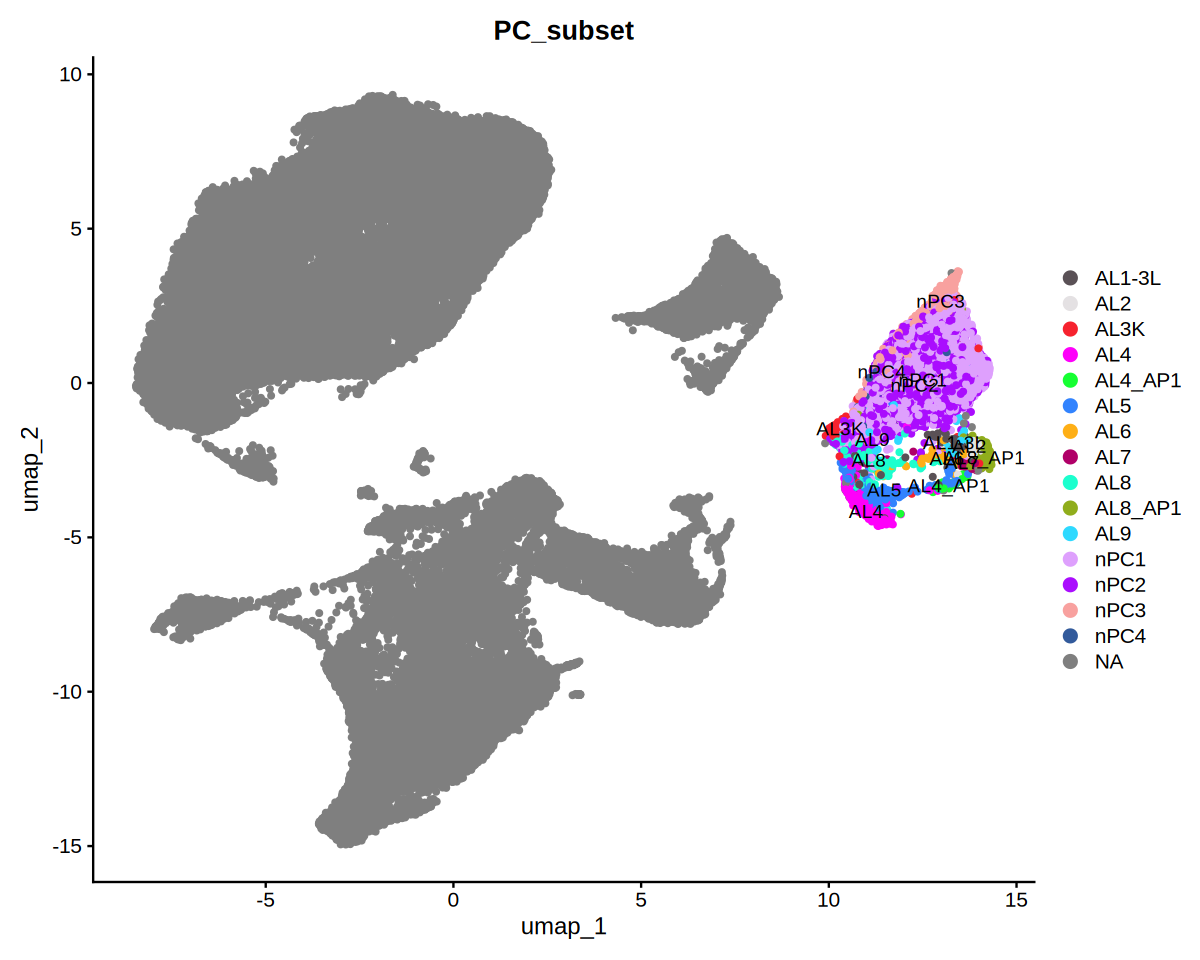

In [7]:
library(scCustomize)
options(repr.plot.height=8,repr.plot.width=10)
DimPlot_scCustom(sce1, pt.size=1,reduction = "umap", group.by = c("PC_subset"),label=T) 

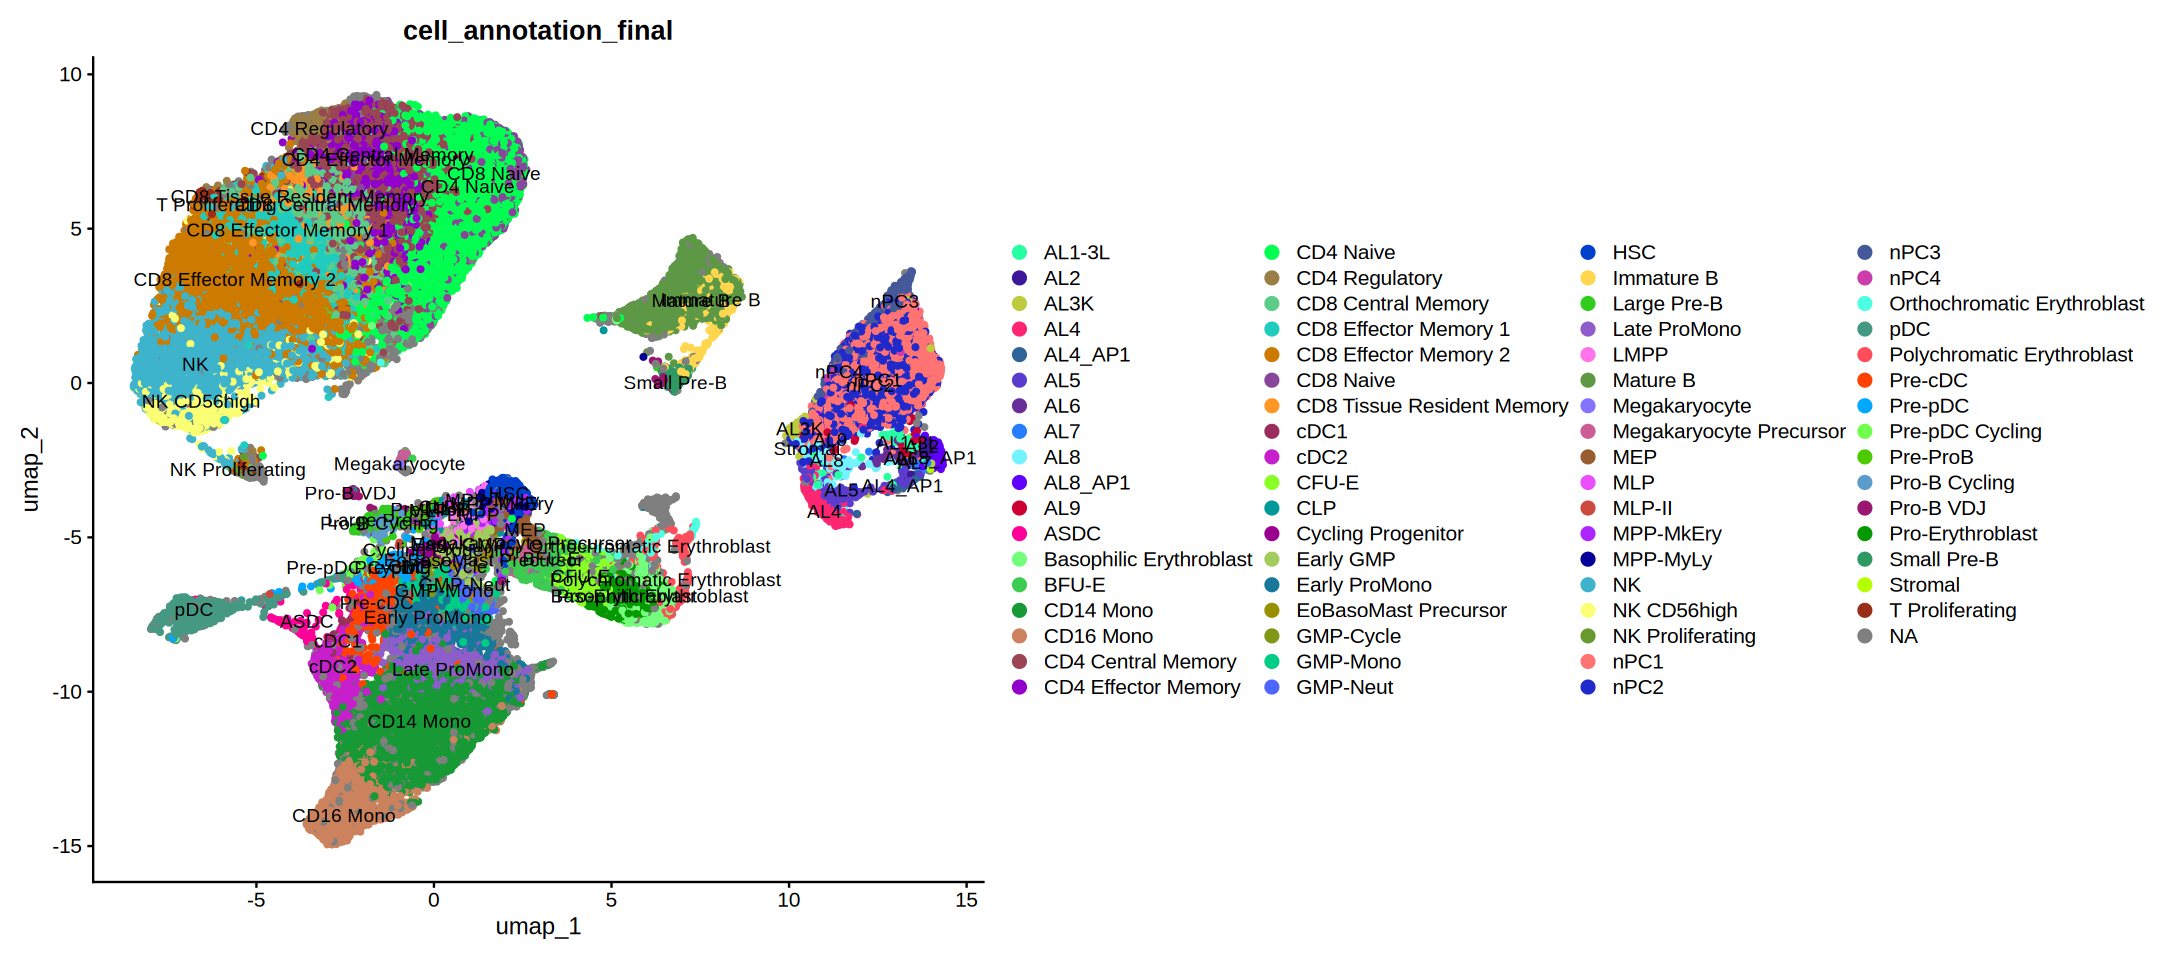

In [8]:
library(scCustomize)
options(repr.plot.height=8,repr.plot.width=18)
DimPlot_scCustom(sce1, pt.size=1,reduction = "umap", group.by = c("cell_annotation_final"),label=T) 

## 3. Subset Seurat object: keep cells in chosen clusters OR in the barcode list


In [9]:
clusters_to_keep <- c(3,17,22,16)

# Subset Seurat object: keep cells in chosen clusters OR in the barcode list
sce1_plasma <- subset(
  sce1,
  subset = (seurat_clusters %in% clusters_to_keep) 
)

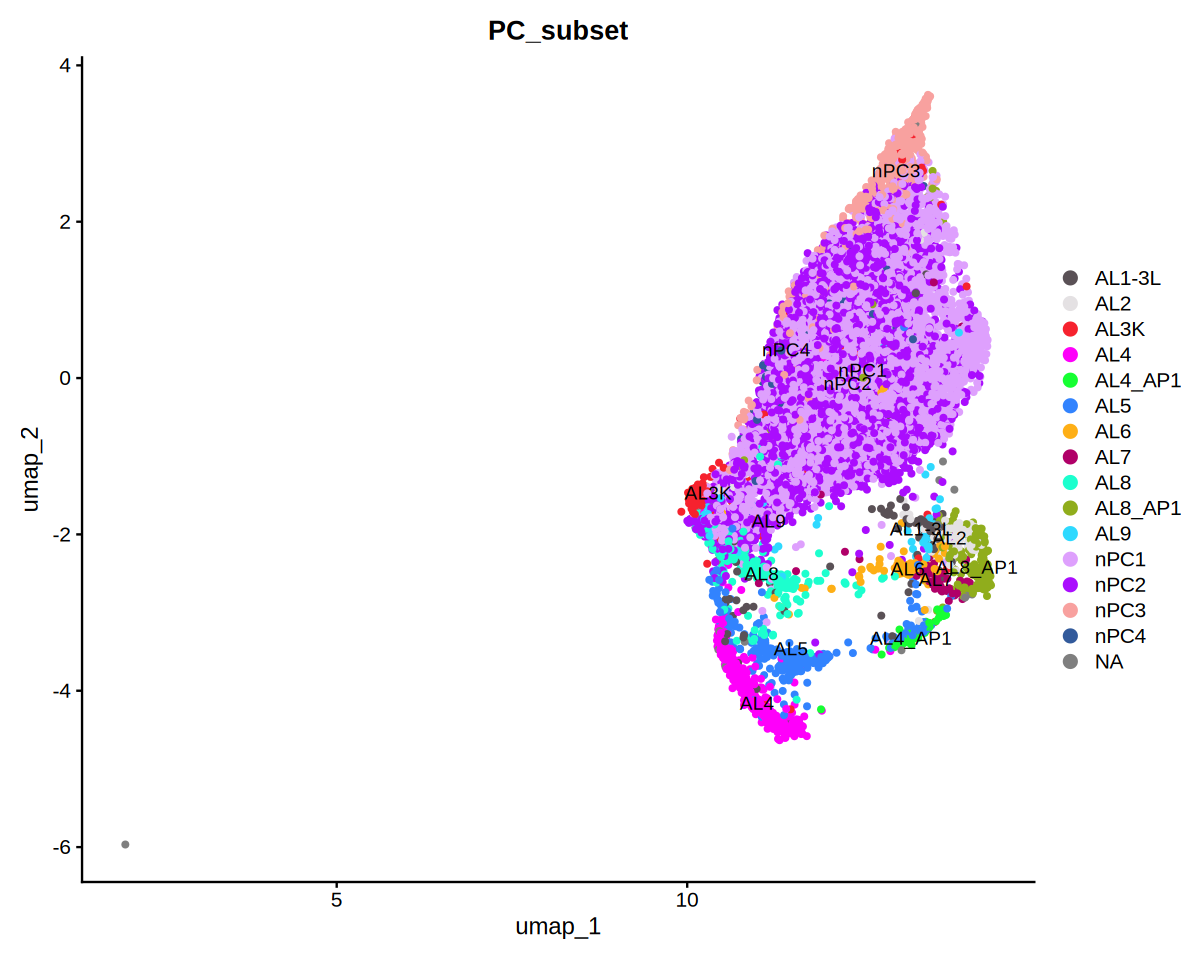

In [10]:
library(scCustomize)
options(repr.plot.height=8,repr.plot.width=10)
DimPlot_scCustom(sce1_plasma, pt.size=1,reduction = "umap", group.by = c("PC_subset"),label=T) 

In [11]:
# run standard anlaysis workflow
sce1_plasma <- NormalizeData(sce1_plasma)
sce1_plasma <- FindVariableFeatures(sce1_plasma)

Normalizing layer: counts

Finding variable features for layer counts



In [12]:
# Step 1: Identify genes starting with "IG"
ig_genes <- grep("^IGK|^IGH|^IGL", rownames(sce1_plasma), value = TRUE)

# Step 2: Exclude these genes from variable features
current_variable_features <- VariableFeatures(sce1_plasma)
filtered_variable_features <- setdiff(current_variable_features, ig_genes)
VariableFeatures(sce1_plasma) <- filtered_variable_features

# Step 3: Proceed with PCA and UMAP
sce1_plasma <- ScaleData(sce1_plasma, features = VariableFeatures(sce1_plasma))
sce1_plasma <- RunPCA(sce1_plasma, features = VariableFeatures(sce1_plasma))

Centering and scaling data matrix

Warning message:
“Different features in new layer data than already exists for scale.data”
PC_ 1 
Positive:  LAMP5, QPCT, RCN3, CTHRC1, CPVL, CTSW, FAM92B, LMF1, CST3, FBP1 
	   P2RX2, SPOCK2, SMOC1, IL5RA, NXPE4, EDNRB, CD9, SLC22A17, PHACTR3, GNG11 
	   FRZB, TNFRSF18, CADM1, CCND1, SYNGR1, NUDT12, AEBP1, AMPD1, TGFBR3L, CCDC151 
Negative:  AHNAK, TAGLN2, COTL1, LSP1, SMCHD1, PPP1R15A, CORO1A, CD52, HSP90AA1, TRIB1 
	   CD99, HLA-DRB1, PELI1, ANXA2, KLF6, ARHGDIB, LIMD2, IQGAP2, SQSTM1, BTG1 
	   NCOA3, MT-ATP8, IRF1, HLA-DRB5, ARL4C, EDEM1, UCP2, HLA-DPB1, PTPRC, SAT1 
PC_ 2 
Positive:  EGR1, KLF6, CADPS2, NR4A1, RHOB, DST, CCDC144A, PELI1, RASSF6, PECAM1 
	   IL6ST, MAFA, HSPB1, ATF3, IGF1, RBMS1, LINC-PINT, RND3, PRPSAP2, WHRN 
	   CDKN1A, DHRS9, ITPRIP, MERTK, CST3, RAB11FIP1, FGD4, LMNA, GADD45A, DEPTOR 
Negative:  HLA-DRB1, HLA-DRB5, CD52, CRIP1, HLA-DPA1, CD99, HLA-DQA1, HCST, HLA-DPB1, C12orf75 
	   HLA-DQB1, PTPRC, RIPOR2, TAGLN2, HLA-DQA2,

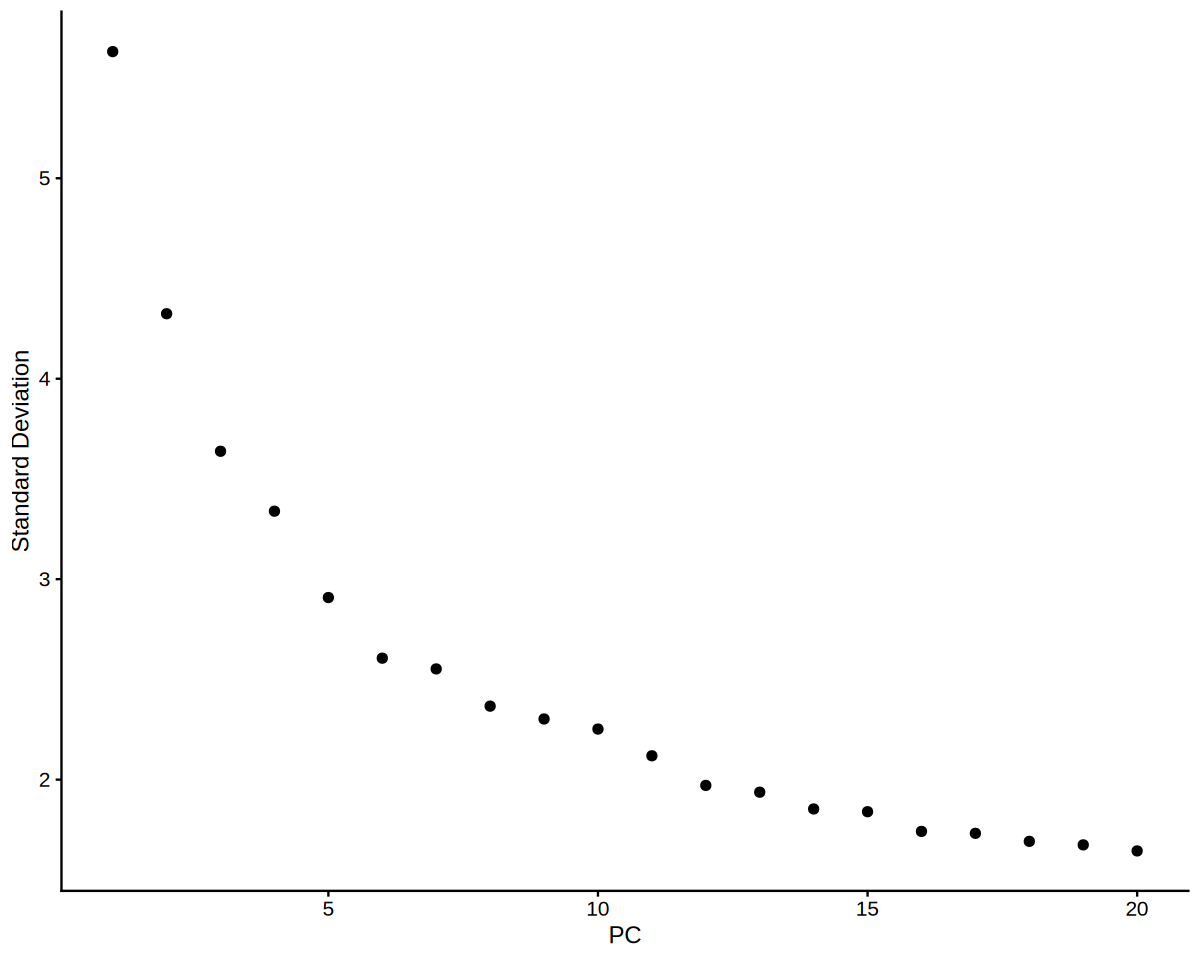

In [13]:
ElbowPlot(sce1_plasma)

## 4. Normalization, integration, and dimensional reduction


In [14]:
sce1_plasma <- FindNeighbors(sce1_plasma, dims = 1:15, reduction = "pca")
sce1_plasma <- FindClusters(sce1_plasma, resolution = 1, cluster.name = "seurat_clusters")

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 10970
Number of edges: 380021

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8175
Number of communities: 19
Elapsed time: 1 seconds


In [15]:
sce1_plasma <- RunUMAP(sce1_plasma, dims = 1:15, reduction = "pca", reduction.name = "UMAP")

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
19:40:56 UMAP embedding parameters a = 0.9922 b = 1.112

19:40:56 Read 10970 rows and found 15 numeric columns

19:40:56 Using Annoy for neighbor search, n_neighbors = 30

19:40:56 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

19:40:57 Writing NN index file to temp file /tmp/RtmpOBAc3g/file1668a93a06e7a5

19:40:57 Searching Annoy index using 1 thread, search_k = 3000

19:41:00 Annoy recall = 100%

19:41:01 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbor

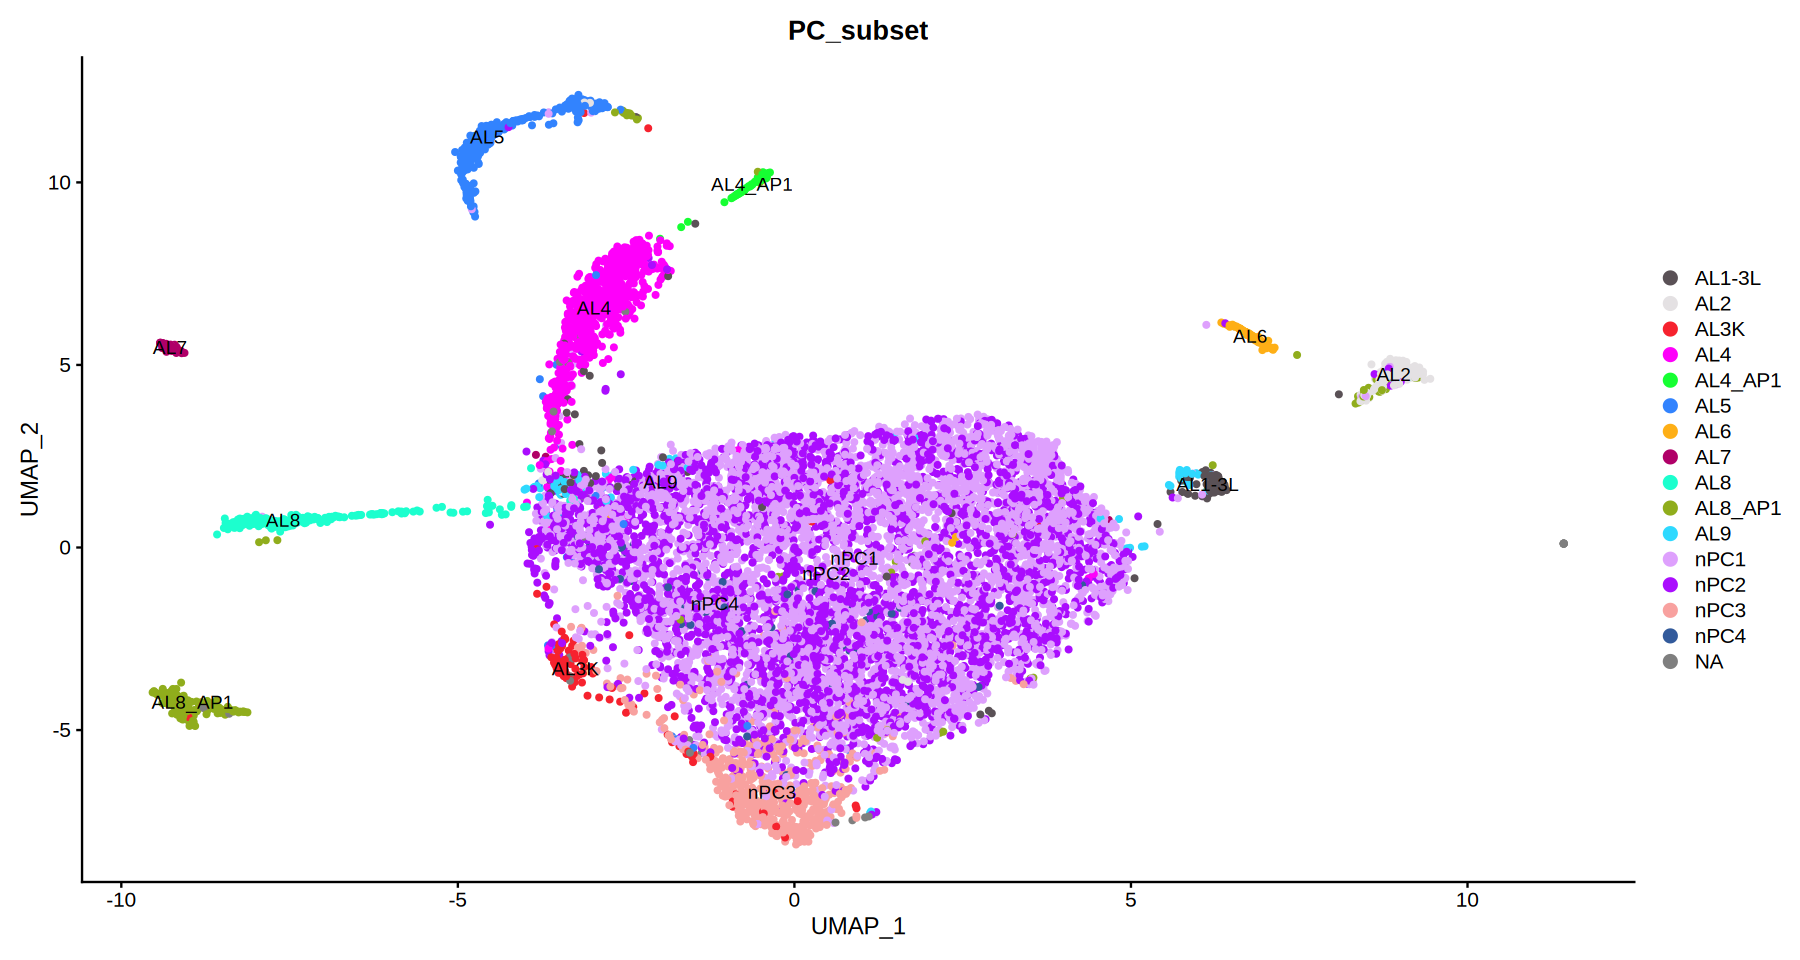

In [16]:
library(scCustomize)
options(repr.plot.height=8,repr.plot.width=15)
DimPlot_scCustom(sce1_plasma, pt.size=1,reduction = "UMAP", group.by = c("PC_subset"),label=T) 

## 5. Packages and setup


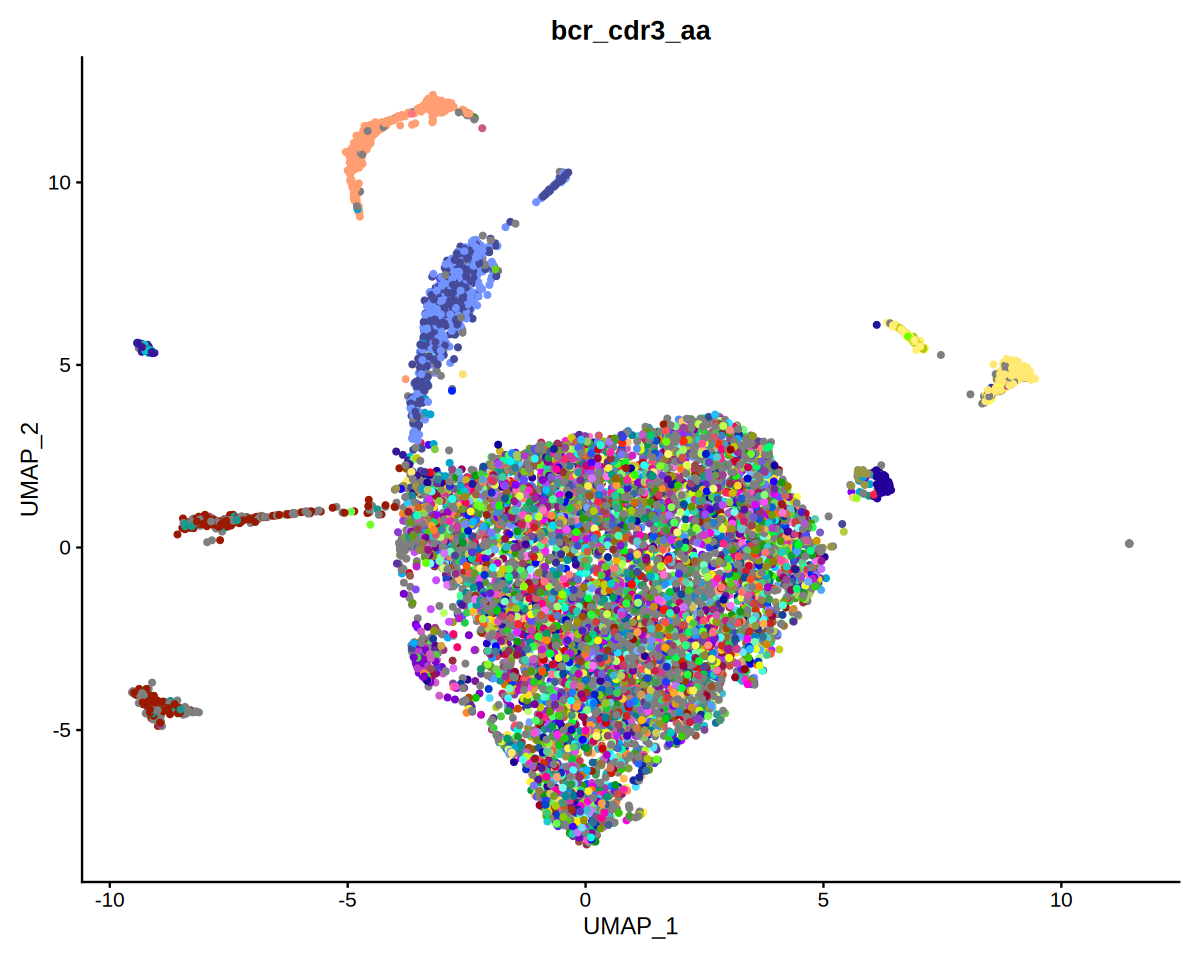

In [17]:
library(scCustomize)
options(repr.plot.height=8,repr.plot.width=10)
DimPlot_scCustom(sce1_plasma, pt.size=1,reduction = "UMAP", group.by = c("bcr_cdr3_aa"),label=F) + theme(legend.position = "none")

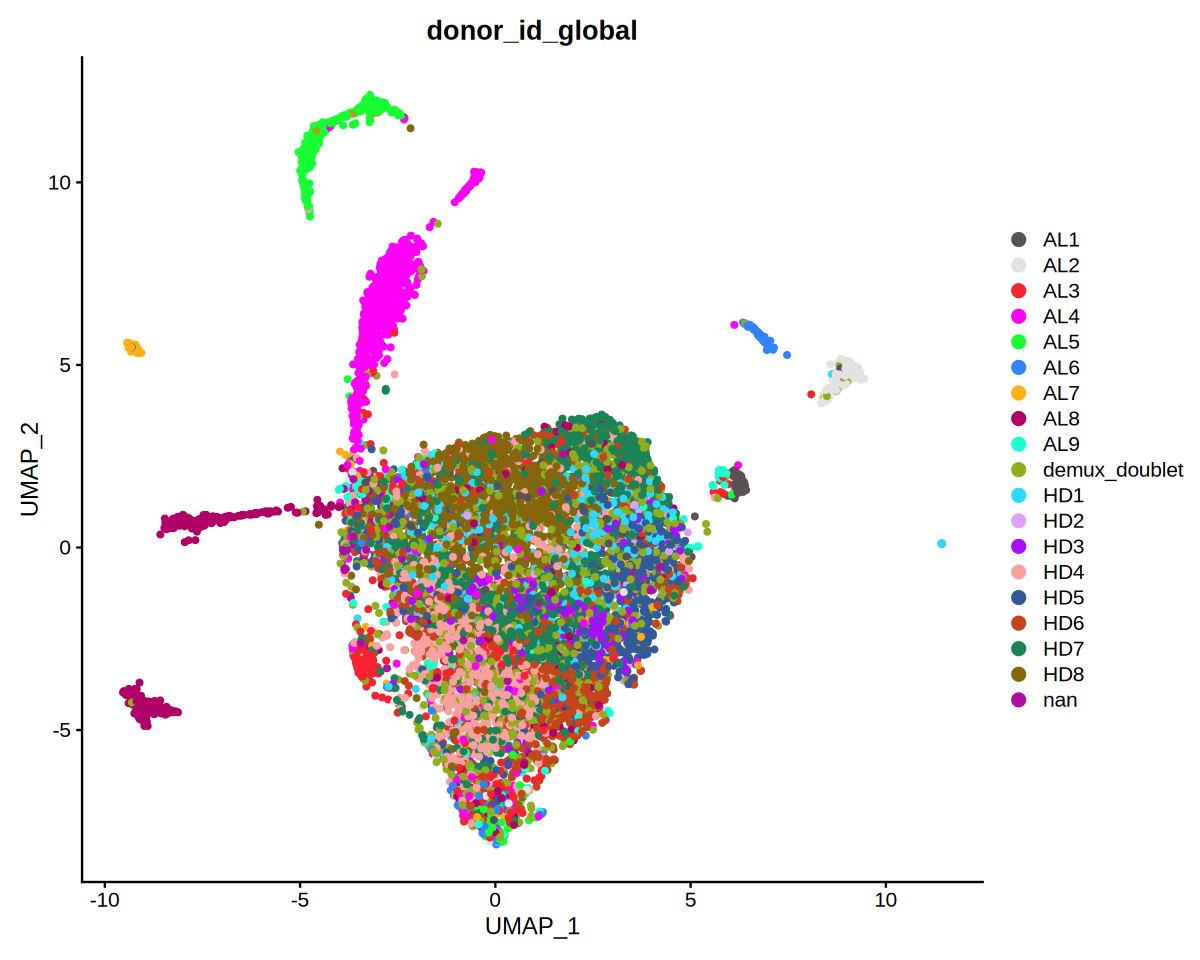

In [18]:
library(scCustomize)
options(repr.plot.height=8,repr.plot.width=10)
DimPlot_scCustom(sce1_plasma, pt.size=1,reduction = "UMAP", group.by = c("donor_id_global"),label=F)

In [19]:
library(Seurat)
library(dplyr)
library(stringr)
library(tibble)
library(purrr)
library(igraph)

# ============================================================
# 0) Parameters
# ============================================================

lev_similarity_cutoff <- 0.85
min_clone_cells <- 2

# ============================================================
# 1) Remove cells with empty / missing bcr_cdr3_aa
# ============================================================

stopifnot("bcr_cdr3_aa" %in% colnames(sce1_plasma@meta.data))
stopifnot("donor_id_global" %in% colnames(sce1_plasma@meta.data))

sce1_plasma_bcr <- subset(
  sce1_plasma,
  subset = !is.na(bcr_cdr3_aa) & bcr_cdr3_aa != ""
)

# Confirm
table(is.na(sce1_plasma_bcr$bcr_cdr3_aa))
sum(sce1_plasma_bcr$bcr_cdr3_aa == "")


# ============================================================
# 2) Prepare metadata
# ============================================================

meta <- sce1_plasma_bcr@meta.data %>%
  rownames_to_column("cell_id") %>%
  mutate(
    PC_subset = as.character(PC_subset),
    bcr_cdr3_aa = as.character(bcr_cdr3_aa),
    is_AL_PC_subset = str_detect(PC_subset, "^AL")
  )


# ============================================================
# 3) Normalize CDR3 sequence sets
#    This makes A;B and B;A identical.
# ============================================================

normalize_cdr3 <- function(x) {
  tokens <- unlist(str_split(as.character(x), ";"))
  tokens <- str_trim(tokens)
  tokens <- tokens[tokens != ""]
  tokens <- unique(tokens)
  tokens <- sort(tokens)
  paste(tokens, collapse = ";")
}

cdr3_tokens <- function(x) {
  tokens <- unlist(str_split(normalize_cdr3(x), ";"))
  tokens <- str_trim(tokens)
  tokens[tokens != ""]
}

meta <- meta %>%
  mutate(
    bcr_cdr3_norm = map_chr(bcr_cdr3_aa, normalize_cdr3)
  )


# ============================================================
# 4) Define CDR3 similarity
# ============================================================

cdr3_similarity <- function(x, y) {
  x_norm <- normalize_cdr3(x)
  y_norm <- normalize_cdr3(y)
  
  x_tok <- cdr3_tokens(x_norm)
  y_tok <- cdr3_tokens(y_norm)
  
  shared_n <- length(intersect(x_tok, y_tok))
  union_n <- length(union(x_tok, y_tok))
  jaccard <- ifelse(union_n == 0, 0, shared_n / union_n)
  
  # One CDR3 set is contained in the other
  # Example: CLSYTTNSTLVF and CATLANWGYYFDFW;CLSYTTNSTLVF
  subset_match <- all(x_tok %in% y_tok) || all(y_tok %in% x_tok)
  
  edit_dist <- utils::adist(x_norm, y_norm)[1, 1]
  max_len <- max(nchar(x_norm), nchar(y_norm))
  lev_similarity <- ifelse(max_len == 0, 0, 1 - edit_dist / max_len)
  
  tibble(
    cdr3_1 = x_norm,
    cdr3_2 = y_norm,
    shared_cdr3_n = shared_n,
    total_unique_cdr3_n = union_n,
    jaccard_similarity = jaccard,
    levenshtein_similarity = lev_similarity,
    subset_match = subset_match,
    similar = subset_match | lev_similarity >= lev_similarity_cutoff
  )
}


# ============================================================
# 5) Cluster similar CDR3 signatures within each AL PC_subset
# ============================================================

cluster_cdr3_within_subset <- function(df) {
  
  sig_df <- df %>%
    count(PC_subset, bcr_cdr3_norm, name = "n_cells") %>%
    arrange(desc(n_cells))
  
  if (nrow(sig_df) == 1) {
    sig_df$clone_component <- 1
    return(sig_df)
  }
  
  pairs <- combn(sig_df$bcr_cdr3_norm, 2, simplify = FALSE)
  
  sim_df <- map_dfr(pairs, function(p) {
    cdr3_similarity(p[1], p[2])
  })
  
  edges <- sim_df %>%
    filter(similar) %>%
    select(cdr3_1, cdr3_2)
  
  g <- graph_from_data_frame(
    d = edges,
    vertices = sig_df$bcr_cdr3_norm,
    directed = FALSE
  )
  
  comp <- components(g)$membership
  
  sig_df %>%
    mutate(
      clone_component = as.integer(comp[bcr_cdr3_norm])
    )
}


al_signature_clusters <- meta %>%
  filter(is_AL_PC_subset) %>%
  group_by(PC_subset) %>%
  group_split() %>%
  map_dfr(cluster_cdr3_within_subset)


# ============================================================
# 6) Compute clonotypes after similarity grouping
#    This replaces the original exact group_by(PC_subset, bcr_cdr3_aa)
# ============================================================

al_clonotype_df <- al_signature_clusters %>%
  group_by(PC_subset, clone_component) %>%
  summarise(
    n_cells = sum(n_cells),
    n_cdr3_signatures = n(),
    representative_cdr3 = bcr_cdr3_norm[which.max(n_cells)],
    all_cdr3_signatures = paste(bcr_cdr3_norm, collapse = " | "),
    .groups = "drop"
  ) %>%
  filter(n_cells >= min_clone_cells) %>%
  group_by(PC_subset) %>%
  arrange(desc(n_cells), .by_group = TRUE) %>%
  mutate(
    clonotype = paste0(PC_subset, "_clone_", row_number())
  ) %>%
  ungroup()

# Inspect clonotypes
al_clonotype_df %>%
  arrange(PC_subset, desc(n_cells)) %>%
  as_tibble() %>%
  print(n = 100)


# ============================================================
# 7) Map each normalized CDR3 signature to similarity-based clone
#    Fixed: avoid n_cells.x / n_cells.y conflict
# ============================================================

signature_to_clone <- al_signature_clusters %>%
  rename(signature_n_cells = n_cells) %>%
  left_join(
    al_clonotype_df %>%
      select(
        PC_subset,
        clone_component,
        clonotype,
        clone_n_cells = n_cells,
        n_cdr3_signatures,
        representative_cdr3
      ),
    by = c("PC_subset", "clone_component")
  ) %>%
  select(
    PC_subset,
    bcr_cdr3_norm,
    clonotype,
    clone_n_cells,
    n_cdr3_signatures,
    representative_cdr3
  )

# ============================================================
# 8) Add clonotype annotation back to metadata
#    All cells not assigned to expanded AL clone become polyclonal.
# ============================================================

meta2 <- meta %>%
  left_join(
    signature_to_clone,
    by = c("PC_subset", "bcr_cdr3_norm")
  ) %>%
  mutate(
    clonotype = ifelse(
      is.na(clonotype),
      "polyclonal",
      clonotype
    ),
    bcr_clone_size = ifelse(
      clonotype == "polyclonal",
      NA,
      clone_n_cells
    ),
    bcr_clone_n_cdr3_signatures = ifelse(
      clonotype == "polyclonal",
      NA,
      n_cdr3_signatures
    ),
    bcr_clone_representative_cdr3 = ifelse(
      clonotype == "polyclonal",
      NA,
      representative_cdr3
    )
  )


# ============================================================
# 9) Add back to Seurat object
# ============================================================

sce1_plasma_bcr$bcr_cdr3_norm <- meta2$bcr_cdr3_norm[
  match(colnames(sce1_plasma_bcr), meta2$cell_id)
]

sce1_plasma_bcr$clonotype <- meta2$clonotype[
  match(colnames(sce1_plasma_bcr), meta2$cell_id)
]

sce1_plasma_bcr$bcr_clone_size <- meta2$bcr_clone_size[
  match(colnames(sce1_plasma_bcr), meta2$cell_id)
]

sce1_plasma_bcr$bcr_clone_n_cdr3_signatures <- meta2$bcr_clone_n_cdr3_signatures[
  match(colnames(sce1_plasma_bcr), meta2$cell_id)
]

sce1_plasma_bcr$bcr_clone_representative_cdr3 <- meta2$bcr_clone_representative_cdr3[
  match(colnames(sce1_plasma_bcr), meta2$cell_id)
]


# ============================================================
# 10) Confirm clone assignment
# ============================================================

table(sce1_plasma_bcr$clonotype, useNA = "ifany")

bcr_clone_counts <- sce1_plasma_bcr@meta.data %>%
  as_tibble() %>%
  count(
    PC_subset,
    clonotype,
    name = "n_cells"
  ) %>%
  arrange(PC_subset, desc(n_cells))

bcr_clone_counts %>%
  print(n = 200)


Attaching package: ‘dplyr’


The following object is masked from ‘package:Biobase’:

    combine


The following objects are masked from ‘package:GenomicRanges’:

    intersect, setdiff, union


The following object is masked from ‘package:GenomeInfoDb’:

    intersect


The following objects are masked from ‘package:IRanges’:

    collapse, desc, intersect, setdiff, slice, union


The following objects are masked from ‘package:S4Vectors’:

    first, intersect, rename, setdiff, setequal, union


The following objects are masked from ‘package:BiocGenerics’:

    combine, intersect, setdiff, union


The following object is masked from ‘package:matrixStats’:

    count


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘purrr’


The following object is masked from ‘package:GenomicRanges’:

    reduce


The following object is masked from ‘package:


FALSE 
 8789 

[1] 0

# A tibble: 19 × 7
   PC_subset clone_component n_cells n_cdr3_signatures representative_cdr3      
   <chr>               <dbl>   <int>             <int> <chr>                    
 1 AL1-3L                  1      89                 2 CSLYKDTATFF              
 2 AL1-3L                  2      22                 1 CTSYTSSSTWVF             
 3 AL1-3L                  3       4                 2 CATLANWGYYFDFW;CLSYTTNST…
 4 AL2                     1     135                 2 CQSYDDNTHVIF;CTTDADIIDHR…
 5 AL2                     2       3                 1 CQSWDNATVLF              
 6 AL3K                    1      77                 3 CAKDGGDYFDHW;CATTRHWDYEY…
 7 AL3K                    2       2                 1 CATLANWGYYFDFW;CLSYTTNST…
 8 AL4                     1     676                 2 CATLANWGYYFDFW;CLSYTTNST…
 9 AL4                     2       2                 1 CARVWGPYYDIETGYYTENYALDV…
10 AL4_AP1                 1      71                 1 CATLANWGYYFDFW;CLSYTTNST…
11 AL5   


 AL1-3L_clone_1  AL1-3L_clone_2  AL1-3L_clone_3     AL2_clone_1     AL2_clone_2 
             89              22               4             135               3 
   AL3K_clone_1    AL3K_clone_2 AL4_AP1_clone_1     AL4_clone_1     AL4_clone_2 
             77               2              71             676               2 
    AL5_clone_1     AL5_clone_2     AL6_clone_1     AL7_clone_1 AL8_AP1_clone_1 
            296               3              89              59              92 
AL8_AP1_clone_2 AL8_AP1_clone_3     AL8_clone_1     AL9_clone_1      polyclonal 
             17               5             151              40            6956 

# A tibble: 33 × 3
   PC_subset clonotype       n_cells
   <chr>     <chr>             <int>
 1 AL1-3L    AL1-3L_clone_1       89
 2 AL1-3L    AL1-3L_clone_2       22
 3 AL1-3L    AL1-3L_clone_3        4
 4 AL1-3L    polyclonal            4
 5 AL2       AL2_clone_1         135
 6 AL2       AL2_clone_2           3
 7 AL2       polyclonal            3
 8 AL3K      AL3K_clone_1         77
 9 AL3K      polyclonal           30
10 AL3K      AL3K_clone_2          2
11 AL4       AL4_clone_1         676
12 AL4       polyclonal           11
13 AL4       AL4_clone_2           2
14 AL4_AP1   AL4_AP1_clone_1      71
15 AL5       AL5_clone_1         296
16 AL5       polyclonal           10
17 AL5       AL5_clone_2           3
18 AL6       AL6_clone_1          89
19 AL6       polyclonal            1
20 AL7       AL7_clone_1          59
21 AL7       polyclonal            1
22 AL8       AL8_clone_1         151
23 AL8_AP1   AL8_AP1_clone_1      92
24 AL8_AP1   AL8_AP1_clone_2      17
25 AL8_AP1   polycl

Ratio of amyloid clones to normal polyclone


Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard




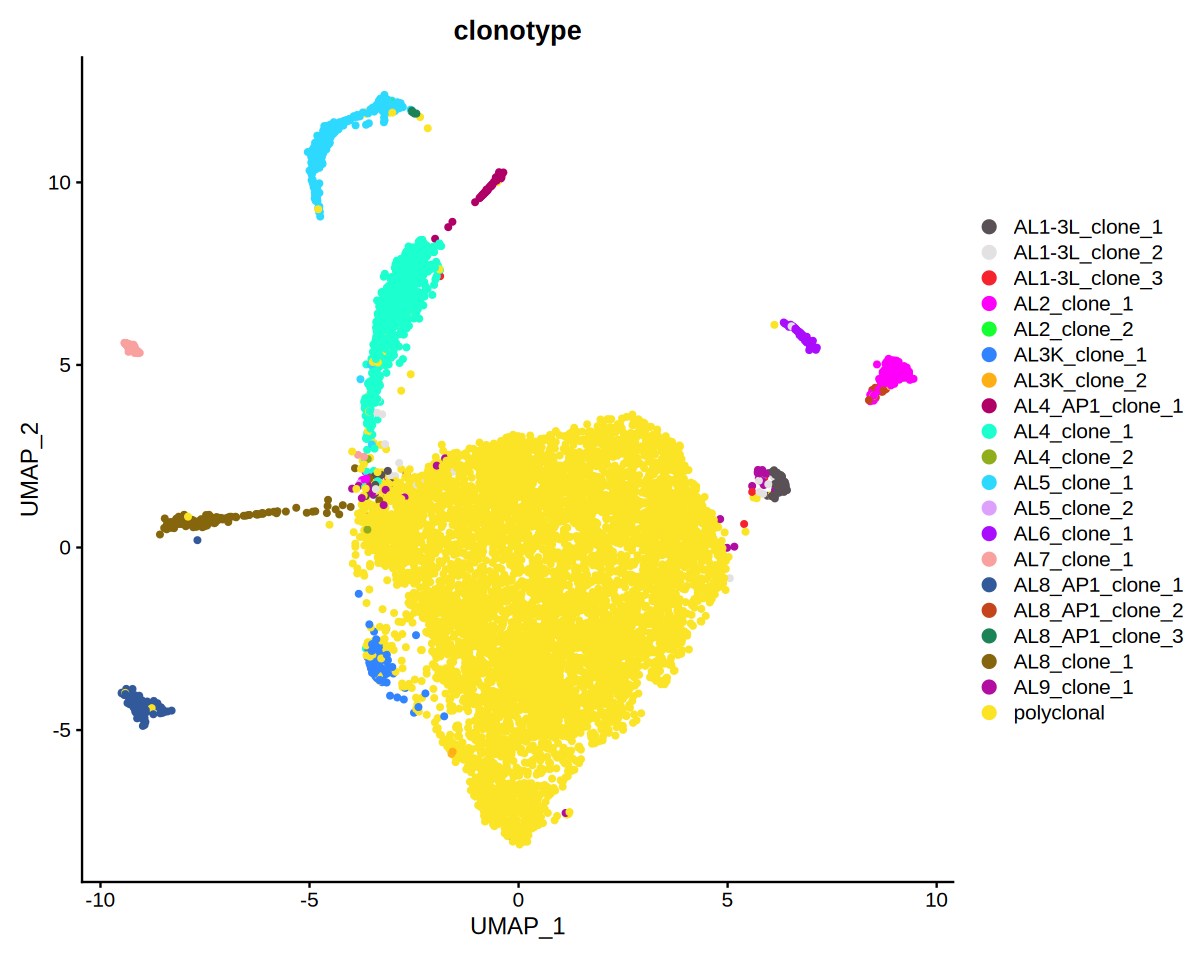

In [20]:
library(Seurat)
library(scCustomize)
library(dplyr)
library(tibble)
library(ggplot2)
library(patchwork)
library(scales)

# ============================================================
# 0) UMAP reference plot
# ============================================================

options(repr.plot.height = 8, repr.plot.width = 10)

p_umap_clone <- DimPlot_scCustom(
  sce1_plasma_bcr,
  pt.size = 1,
  reduction = "UMAP",
  group.by = "clonotype",
  label = FALSE
)

p_umap_clone


Attaching package: ‘tidyr’


The following object is masked from ‘package:igraph’:

    crossing


The following objects are masked from ‘package:Matrix’:

    expand, pack, unpack


The following object is masked from ‘package:S4Vectors’:

    expand




AL4_clone_1     AL5_clone_1     AL8_clone_1     AL2_clone_1 AL8_AP1_clone_1 
      "#5A5156"       "#E4E1E3"       "#F6222E"       "#FE00FA"       "#16FF32" 
 AL1-3L_clone_1     AL6_clone_1    AL3K_clone_1 AL4_AP1_clone_1     AL7_clone_1 
      "#3283FE"       "#FEAF16"       "#B00068"       "#1CFFCE"       "#90AD1C" 
    AL9_clone_1  AL1-3L_clone_2 AL8_AP1_clone_2 AL8_AP1_clone_3  AL1-3L_clone_3 
      "#2ED9FF"       "#DEA0FD"       "#AA0DFE"       "#F8A19F"       "#325A9B" 
    AL2_clone_2     AL5_clone_2    AL3K_clone_2     AL4_clone_2      polyclonal 
      "#C4451C"       "#1C8356"       "#85660D"       "#B10DA1"        "grey80"

[1] FALSE


    AL4_clone_1     AL5_clone_1     AL8_clone_1     AL2_clone_1 AL8_AP1_clone_1 
            676             296             151             135              92 
 AL1-3L_clone_1     AL6_clone_1    AL3K_clone_1 AL4_AP1_clone_1     AL7_clone_1 
             89              89              77              71              59 
    AL9_clone_1  AL1-3L_clone_2 AL8_AP1_clone_2 AL8_AP1_clone_3  AL1-3L_clone_3 
             40              22              17               5               4 
    AL2_clone_2     AL5_clone_2    AL3K_clone_2     AL4_clone_2      polyclonal 
              3               3               2               2            6956 

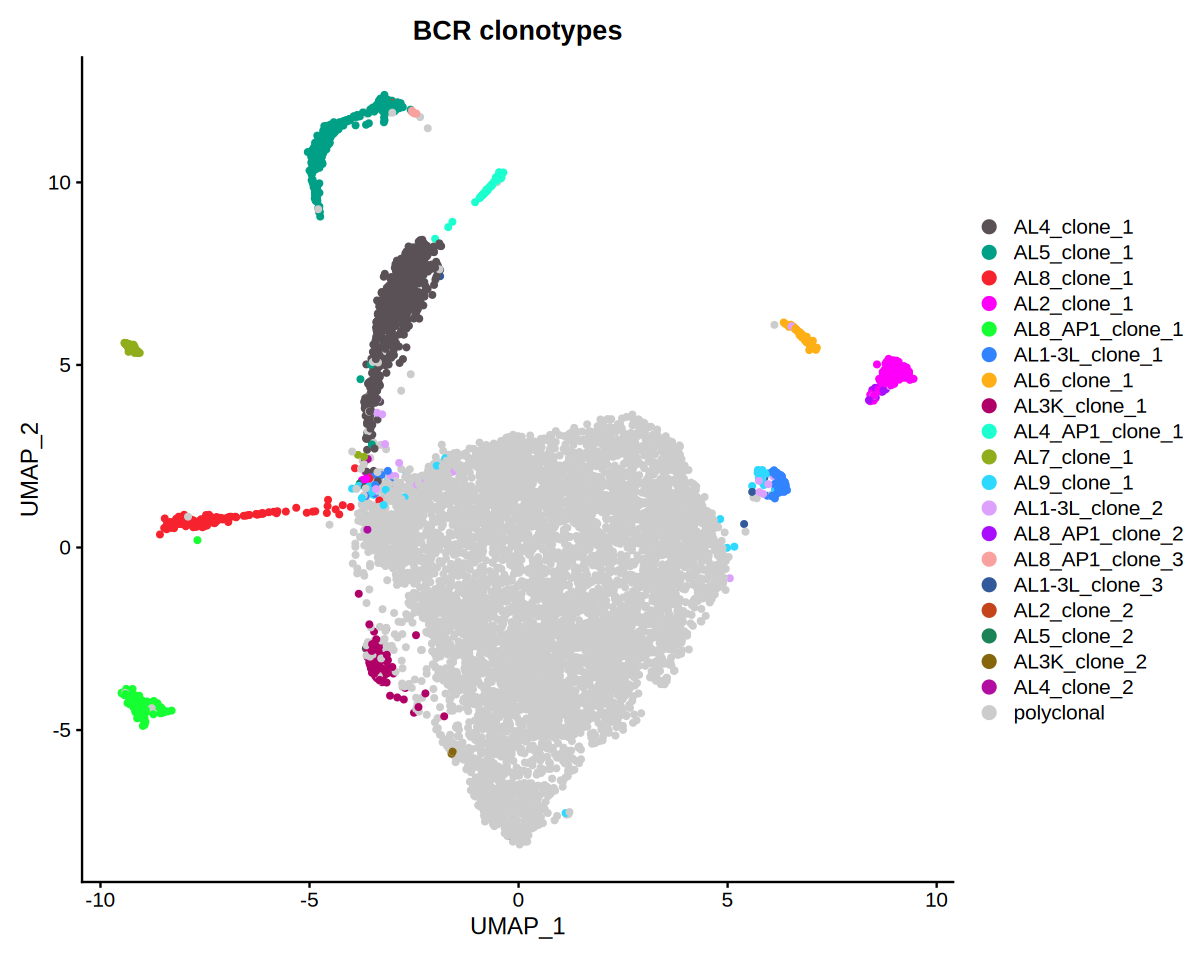

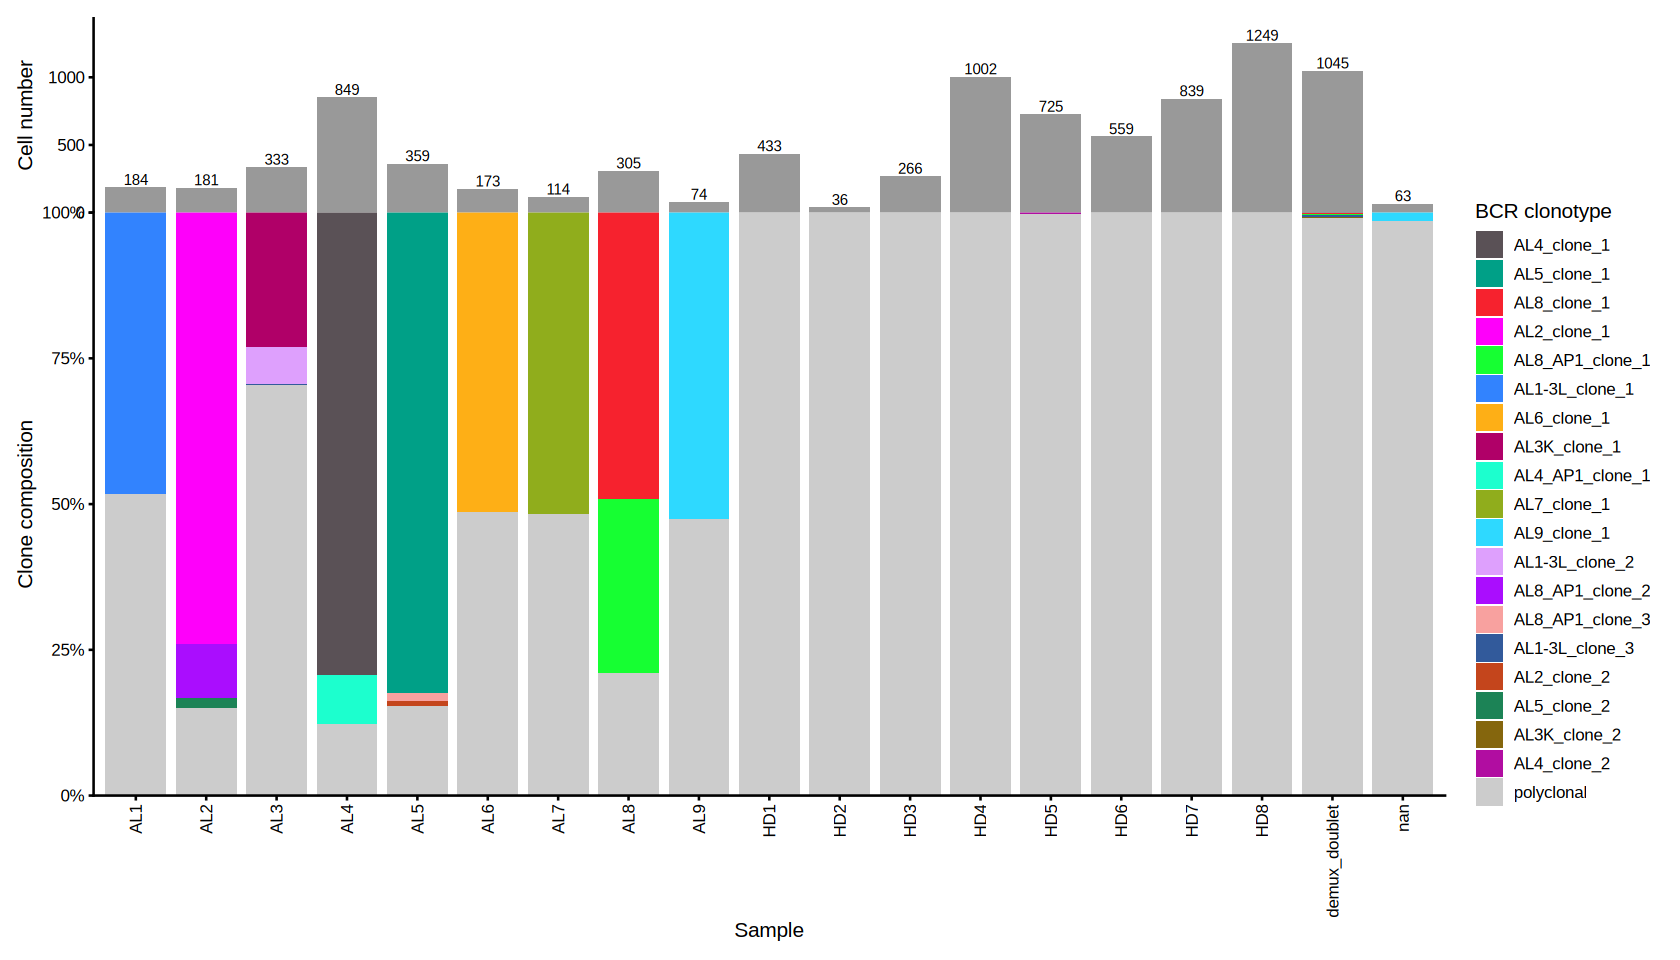

In [21]:
library(Seurat)
library(scCustomize)
library(dplyr)
library(tidyr)
library(tibble)
library(stringr)
library(ggplot2)
library(patchwork)
library(scales)
library(Polychrome)

# ============================================================
# 0) Settings
# ============================================================

obj <- sce1_plasma_bcr

clone_col <- "clonotype"
sample_col <- "donor_id_global"

stopifnot(clone_col %in% colnames(obj@meta.data))
stopifnot(sample_col %in% colnames(obj@meta.data))

# Optional: only keep AL samples
# obj <- subset(obj, subset = grepl("^AL", donor_id_global))


# ============================================================
# 1) Prepare metadata
# ============================================================

meta_plot <- obj@meta.data %>%
  rownames_to_column("cell_id") %>%
  mutate(
    sample_id = as.character(.data[[sample_col]]),
    clone_id  = as.character(.data[[clone_col]])
  ) %>%
  filter(!is.na(sample_id), !is.na(clone_id))

# Make sure polyclonal is present as text, not NA
meta_plot <- meta_plot %>%
  mutate(
    clone_id = ifelse(is.na(clone_id) | clone_id == "", "polyclonal", clone_id)
  )


# ============================================================
# 2) Define sample order
# ============================================================

sample_order <- meta_plot %>%
  count(sample_id, name = "total_cells") %>%
  arrange(sample_id) %>%
  pull(sample_id)

# Alternative: order samples by total cell number
# sample_order <- meta_plot %>%
#   count(sample_id, name = "total_cells") %>%
#   arrange(desc(total_cells)) %>%
#   pull(sample_id)


# ============================================================
# 3) Define clone order
#    Expanded clones first, polyclonal last
# ============================================================

clone_order <- meta_plot %>%
  count(clone_id, name = "clone_cells") %>%
  arrange(desc(clone_cells)) %>%
  pull(clone_id)

clone_order <- unique(clone_order)

clone_order <- c(
  setdiff(clone_order, "polyclonal"),
  intersect("polyclonal", clone_order)
)

meta_plot <- meta_plot %>%
  mutate(
    sample_id = factor(sample_id, levels = sample_order),
    clone_id  = factor(clone_id, levels = clone_order)
  )


# ============================================================
# 4) Generate one fixed color vector for clones
#    This vector will be used for BOTH UMAP and stack plot.
# ============================================================

n_clone <- length(clone_order)

if (n_clone <= 36) {
  clone_cols <- Polychrome::palette36.colors(n_clone)
} else {
  clone_cols <- grDevices::hcl.colors(n_clone, palette = "Dynamic")
}

names(clone_cols) <- clone_order

# Force polyclonal to gray
if ("polyclonal" %in% names(clone_cols)) {
  clone_cols["polyclonal"] <- "grey80"
}

# Check color vector
clone_cols
any(duplicated(names(clone_cols)))

names(clone_cols) <- clone_order

# Replace the platelet/background-like light gray color
clone_cols[clone_cols == "#E4E1E3"] <- "#00A087"  # 可换成你喜欢的非灰色

# Force polyclonal to gray
if ("polyclonal" %in% names(clone_cols)) {
  clone_cols["polyclonal"] <- "grey80"
}

# ============================================================
# 5) Add ordered clone label back to Seurat object
# ============================================================

obj$clone_id_plot <- as.character(obj@meta.data[[clone_col]])
obj$clone_id_plot[is.na(obj$clone_id_plot) | obj$clone_id_plot == ""] <- "polyclonal"

obj$clone_id_plot <- factor(
  obj$clone_id_plot,
  levels = clone_order
)

# Confirm
table(obj$clone_id_plot, useNA = "ifany")

# ============================================================
# 6) UMAP with same clone colors
# ============================================================

options(repr.plot.height = 8, repr.plot.width = 10)

p_umap_clone <- DimPlot_scCustom(
  obj,
  pt.size = 1,
  reduction = "UMAP",
  group.by = "clone_id_plot",
  label = FALSE,
  colors_use = clone_cols
) +
  ggtitle("BCR clonotypes")

p_umap_clone

# ============================================================
# 7) Clone composition per sample
# ============================================================

clone_comp_df <- meta_plot %>%
  count(sample_id, clone_id, name = "n_cells") %>%
  group_by(sample_id) %>%
  mutate(
    total_cells = sum(n_cells),
    fraction = n_cells / total_cells
  ) %>%
  ungroup()

sample_size_df <- meta_plot %>%
  count(sample_id, name = "total_cells") %>%
  mutate(
    sample_id = factor(sample_id, levels = sample_order)
  )


# ============================================================
# 8) Top gray bar plot: total cell number per sample
# ============================================================

p_cell_number <- ggplot(
  sample_size_df,
  aes(x = sample_id, y = total_cells)
) +
  geom_col(
    fill = "grey60",
    width = 0.85
  ) +
  geom_text(
    aes(label = total_cells),
    vjust = -0.25,
    size = 3
  ) +
  scale_y_continuous(
    expand = expansion(mult = c(0, 0.15))
  ) +
  labs(
    x = NULL,
    y = "Cell number"
  ) +
  theme_classic(base_size = 12) +
  theme(
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line.x = element_blank(),
    plot.margin = margin(5.5, 5.5, 0, 5.5)
  )


# ============================================================
# 9) Bottom stacked bar plot: clone composition per sample
# ============================================================

p_clone_stack <- ggplot(
  clone_comp_df,
  aes(x = sample_id, y = fraction, fill = clone_id)
) +
  geom_col(
    width = 0.85,
    color = NA
  ) +
  scale_fill_manual(
    values = clone_cols,
    breaks = clone_order,
    drop = FALSE
  ) +
  scale_y_continuous(
    labels = percent_format(accuracy = 1),
    expand = expansion(mult = c(0, 0))
  ) +
  labs(
    x = "Sample",
    y = "Clone composition",
    fill = "BCR clonotype"
  ) +
  theme_classic(base_size = 12) +
  theme(
    axis.text.x = element_text(
      angle = 90,
      hjust = 1,
      vjust = 0.5
    ),
    legend.position = "right",
    plot.margin = margin(0, 5.5, 5.5, 5.5)
  )


# ============================================================
# 10) Combine top cell-number bar and bottom stacked clone plot
# ============================================================

p_clone_composition <- p_cell_number / p_clone_stack +
  plot_layout(heights = c(1, 3))

options(repr.plot.height = 8, repr.plot.width = 14)
p_clone_composition

## 6. Clonotype assignment and repertoire analysis


In [22]:
library(Seurat)
library(dplyr)
library(stringr)

# ============================================================
# 0) Check metadata columns
# ============================================================

colnames(sce1_plasma_bcr@meta.data)

# Make sure these exist
sample_col <- "donor_id_global"
clone_col  <- "clonotype"

stopifnot(sample_col %in% colnames(sce1_plasma_bcr@meta.data))
stopifnot(clone_col  %in% colnames(sce1_plasma_bcr@meta.data))

# ============================================================
# 1) Clean metadata
# ============================================================

sce1_plasma_bcr@meta.data[[sample_col]] <- as.character(
  sce1_plasma_bcr@meta.data[[sample_col]]
)

sce1_plasma_bcr@meta.data[[clone_col]] <- as.character(
  sce1_plasma_bcr@meta.data[[clone_col]]
)

# ============================================================
# 2) Remove samples starting with demux or nan
#    Use metadata indexing, not subset = expression
# ============================================================

keep_cells_1 <- rownames(sce1_plasma_bcr@meta.data)[
  !str_detect(
    sce1_plasma_bcr@meta.data[[sample_col]],
    regex("^(demux|nan)", ignore_case = TRUE)
  )
]

sce1_plasma_bcr_plot <- subset(
  sce1_plasma_bcr,
  cells = keep_cells_1
)

# ============================================================
# 3) Create sample-clonotype identity
# ============================================================

sce1_plasma_bcr_plot@meta.data$sampleclonotype <- paste(
  sce1_plasma_bcr_plot@meta.data[[sample_col]],
  sce1_plasma_bcr_plot@meta.data[[clone_col]],
  sep = "_"
)

# ============================================================
# 4) Remove sample-clonotype groups with <3 cells
# ============================================================

sampleclonotype_counts <- table(
  sce1_plasma_bcr_plot@meta.data$sampleclonotype
)

keep_sampleclonotype <- names(sampleclonotype_counts)[
  sampleclonotype_counts >= 3
]

keep_cells_2 <- rownames(sce1_plasma_bcr_plot@meta.data)[
  sce1_plasma_bcr_plot@meta.data$sampleclonotype %in% keep_sampleclonotype
]

sce1_plasma_bcr_plot <- subset(
  sce1_plasma_bcr_plot,
  cells = keep_cells_2
)

# ============================================================
# 5) Order identities by sample ID, then clone status
# ============================================================

sampleclonotype_order <- sce1_plasma_bcr_plot@meta.data %>%
  as.data.frame() %>%
  mutate(
    donor_id_global = as.character(.data[[sample_col]]),
    clonotype       = as.character(.data[[clone_col]]),

    clone_order = case_when(
      is.na(clonotype) | clonotype %in% c("", "NA", "NaN", "nan") ~ 99,
      str_detect(clonotype, "clone_1$") ~ 1,
      str_detect(clonotype, "clone_2$") ~ 2,
      str_detect(clonotype, "clone_3$") ~ 3,
      str_detect(clonotype, "clone_4$") ~ 4,
      str_detect(clonotype, "clone_5$") ~ 5,
      TRUE ~ 50
    )
  ) %>%
  distinct(donor_id_global, clonotype, sampleclonotype, clone_order) %>%
  arrange(
    donor_id_global,
    clone_order,
    clonotype
  ) %>%
  pull(sampleclonotype)

sce1_plasma_bcr_plot@meta.data$sampleclonotype <- factor(
  sce1_plasma_bcr_plot@meta.data$sampleclonotype,
  levels = sampleclonotype_order
)

Idents(sce1_plasma_bcr_plot) <- "sampleclonotype"

# Confirm
table(Idents(sce1_plasma_bcr_plot))
levels(Idents(sce1_plasma_bcr_plot))

# ============================================================
# 6) Genes to plot
# ============================================================

gene_list_plot <- c(
  "CRIP1",
  "CCND1", 
  "CCND2",
  "CCND3",
  "MYC",
  "MAF",
  "MAFB",
  "FGFR3",
  "NSD2",
  "ITGB7",
  "TNFRSF17",
  "CD38",
  "SDC1"
)

gene_list_plot <- intersect(
  gene_list_plot,
  rownames(sce1_plasma_bcr_plot)
)

# ============================================================
# 7) Plot
# ============================================================

options(repr.plot.height = 10, repr.plot.width = 14)

Stacked_VlnPlot(
  seurat_object = sce1_plasma_bcr_plot, 
  features = gene_list_plot, 
  x_lab_rotate = TRUE
)

[1] "orig.ident"                    "nCount_RNA"                   
 [3] "nFeature_RNA"                  "sample_id_raw"                
 [5] "cell_id_raw_counts"            "sample_id_from_cell_id"       
 [7] "sample_id_for_matching"        "barcode_core_from_counts"     
 [9] "sample_group_inferred"         "disease_inferred"             
[11] "CD138_fraction_inferred"       "meta_cell_id_metadata"        
[13] "meta_library_name"             "donor_id_global"              
[15] "condition"                     "PC_subset"                    
[17] "projected_CellType"            "cell_annotation_from_metadata"
[19] "CD138_fraction"                "metadata_source_file"         
[21] "CD138_fraction_final"          "condition_final"              
[23] "cell_annotation_final"         "percent.mt"                   
[25] "RNA_snn_res.0.5"               "seurat_clusters"              
[27] "has_bcr"                       "n_bcr_chains"                 
[29] "n_bcr_loci"                    "bcr_loci"                     
[31] "bcr_clone_id"                  "n_bcr_clone_ids"              
[33] "bcr_cdr3_aa"                   "bcr_v_call"                   
[35] "bcr_d_call"                    "bcr_j_call"                   
[37] "bcr_c_call"                    "bcr_total_umi"                
[39] "bcr_max_umi"                   "bcr_has_heavy"                
[41] "bcr_has_light"                 "bcr_files"                    
[43] "bcr_cdr3_norm"                 "clonotype"                    
[45] "bcr_clone_size"                "bcr_clone_n_cdr3_signatures"  
[47] "bcr_clone_representative_cdr3"


 AL1_AL1-3L_clone_1      AL1_polyclonal     AL2_AL2_clone_1     AL2_AL5_clone_2 
                 89                  95                 134                   3 
AL2_AL8_AP1_clone_2      AL2_polyclonal    AL3_AL3K_clone_1  AL3_AL1-3L_clone_2 
                 17                  27                  77                  21 
     AL3_polyclonal AL4_AL4_AP1_clone_1     AL4_AL4_clone_1      AL4_polyclonal 
                234                  71                 674                 103 
    AL5_AL5_clone_1     AL5_AL2_clone_2 AL5_AL8_AP1_clone_3      AL5_polyclonal 
                296                   3                   5                  55 
    AL6_AL6_clone_1      AL6_polyclonal     AL7_AL7_clone_1      AL7_polyclonal 
                 89                  84                  59                  55 
AL8_AL8_AP1_clone_1     AL8_AL8_clone_1      AL8_polyclonal     AL9_AL9_clone_1 
                 91                 150                  64                  39 
     AL9_polyclonal      HD

[1] "AL1_AL1-3L_clone_1"  "AL1_polyclonal"      "AL2_AL2_clone_1"    
 [4] "AL2_AL5_clone_2"     "AL2_AL8_AP1_clone_2" "AL2_polyclonal"     
 [7] "AL3_AL3K_clone_1"    "AL3_AL1-3L_clone_2"  "AL3_polyclonal"     
[10] "AL4_AL4_AP1_clone_1" "AL4_AL4_clone_1"     "AL4_polyclonal"     
[13] "AL5_AL5_clone_1"     "AL5_AL2_clone_2"     "AL5_AL8_AP1_clone_3"
[16] "AL5_polyclonal"      "AL6_AL6_clone_1"     "AL6_polyclonal"     
[19] "AL7_AL7_clone_1"     "AL7_polyclonal"      "AL8_AL8_AP1_clone_1"
[22] "AL8_AL8_clone_1"     "AL8_polyclonal"      "AL9_AL9_clone_1"    
[25] "AL9_polyclonal"      "HD1_polyclonal"      "HD2_polyclonal"     
[28] "HD3_polyclonal"      "HD4_polyclonal"      "HD5_polyclonal"     
[31] "HD6_polyclonal"      "HD7_polyclonal"      "HD8_polyclonal"

In [23]:
library(Seurat)
library(sceasy)

# Subset both groups together in one step
subset_cells <- sce1_plasma_bcr

# Ensure RNA assay is properly formatted
subset_cells[["RNA"]] <- as(subset_cells[["RNA"]], "Assay")

# Save as .h5ad
sceasy::convertFormat(subset_cells, from = "seurat", to = "anndata", outFile = "Bianchi.h5ad")


Warning message:
“Assay RNA changing from Assay5 to Assay”
Warning message in .regularise_df(obj@meta.data, drop_single_values = drop_single_values):
“Dropping single category variables:orig.ident, has_bcr, bcr_clone_id, n_bcr_clone_ids, bcr_has_heavy, bcr_has_light”


AnnData object with n_obs × n_vars = 8789 × 25111
    obs: 'nCount_RNA', 'nFeature_RNA', 'sample_id_raw', 'cell_id_raw_counts', 'sample_id_from_cell_id', 'sample_id_for_matching', 'barcode_core_from_counts', 'sample_group_inferred', 'disease_inferred', 'CD138_fraction_inferred', 'meta_cell_id_metadata', 'meta_library_name', 'donor_id_global', 'condition', 'PC_subset', 'projected_CellType', 'cell_annotation_from_metadata', 'CD138_fraction', 'metadata_source_file', 'CD138_fraction_final', 'condition_final', 'cell_annotation_final', 'percent.mt', 'RNA_snn_res.0.5', 'seurat_clusters', 'n_bcr_chains', 'n_bcr_loci', 'bcr_loci', 'bcr_cdr3_aa', 'bcr_v_call', 'bcr_d_call', 'bcr_j_call', 'bcr_c_call', 'bcr_total_umi', 'bcr_max_umi', 'bcr_files', 'bcr_cdr3_norm', 'clonotype', 'bcr_clone_size', 'bcr_clone_n_cdr3_signatures', 'bcr_clone_representative_cdr3'
    var: 'vf_vst_counts.1_mean', 'vf_vst_counts.1_variance', 'vf_vst_counts.1_variance.expected', 'vf_vst_counts.1_variance.standardized', 'vf_

Available assays: RNA

Using assay: RNA

Sample-group cell counts before subsetting:




   AL    HD Other 
 2572  5109  1108 


Sample-group cell counts after subsetting:




  AL   HD 
2572 5109 


Samples retained:



...

Parsing genes from last column: matching proteins in your network (labels)



# A tibble: 11 × 3
   term_description                         n_genes_input n_genes_found
   <chr>                                            <int>         <int>
 1 MHC class II protein complex                         7             7
 2 Immunoglobulin complex                               7             7
 3 MHC II                                               5             5
 4 Glycoprotein                                        42            41
 5 Immunoglobulin                                       3             3
 6 B cell receptor signaling pathway                    9             9
 7 Positive regulation of B cell activation            10            10
 8 Immunoglobulin mediated immune response              9             9
 9 Positive regulation of cell adhesion                15            15
10 B cell differentiation                               6             6
11 B cell proliferation                                 4             4


Scored: score_MHC_class_II_protein_complex_GO_0042613 using 7 genes.

Scored: score_Immunoglobulin_complex_GO_0019814 using 7 genes.

Scored: score_MHC_II_KW_0491 using 5 genes.

Scored: score_Glycoprotein_KW_0325 using 41 genes.

Scored: score_Immunoglobulin_KW_1280 using 3 genes.

Scored: score_B_cell_receptor_signaling_pathway_GO_0050853 using 9 genes.

Scored: score_Positive_regulation_of_B_cell_activation_GO_0050871 using 10 genes.

Scored: score_Immunoglobulin_mediated_immune_response_GO_0016064 using 9 genes.

Scored: score_Positive_regulation_of_cell_adhesion_GO_0045785 using 15 genes.

Scored: score_B_cell_differentiation_GO_0030183 using 6 genes.

Scored: score_B_cell_proliferation_GO_0042100 using 4 genes.

Pooled HD cells used as reference:



# A tibble: 8 × 2
  sample_id_for_analysis n_cells
  <chr>                    <int>
1 HD1                        433
2 HD2                         36
3 HD3                        266
4 HD4                       1002
5 HD5                        725
6 HD6                        559
7 HD7                        839
8 HD8                       1249


sample_id_for_analysis,clone_id_for_analysis,comparison,term_id,term_description,n_clone,n_ref,clone_mean,ref_mean,mean_diff,clone_median,ref_median,median_diff,p_value,FDR,direction
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
AL1,AL1-3L_clone_1,clone_vs_pooled_HD,GO:0030183,B cell differentiation,89,5109,-0.09280309,0.11105377,-0.20385686,-0.111999192,0.10380992,-0.21580911,3.972040e-25,1.054645e-24,clone_lower
AL1,AL1-3L_clone_1,clone_vs_same_sample_polyclone,GO:0030183,B cell differentiation,89,95,-0.09280309,0.01079995,-0.10360304,-0.111999192,-0.01086410,-0.10113510,3.040610e-04,3.985140e-04,clone_lower
AL1,AL1-3L_clone_1,clone_vs_pooled_HD,GO:0042100,B cell proliferation,89,5109,-0.01541138,0.18115852,-0.19656990,-0.005607036,0.18111432,-0.18672136,2.066406e-15,3.880811e-15,clone_lower
AL1,AL1-3L_clone_1,clone_vs_same_sample_polyclone,GO:0042100,B cell proliferation,89,95,-0.01541138,0.03769497,-0.05310635,-0.005607036,0.06787328,-0.07348032,8.147304e-02,8.898474e-02,clone_lower
AL1,AL1-3L_clone_1,clone_vs_pooled_HD,GO:0050853,B cell receptor signaling pathway,89,5109,-0.09839326,0.08497204,-0.18336531,-0.092583730,0.02176195,-0.11434568,7.714040e-19,1.583950e-18,clone_lower
AL1,AL1-3L_clone_1,clone_vs_same_sample_polyclone,GO:0050853,B cell receptor signaling pathway,89,95,-0.09839326,-0.06935502,-0.02903825,-0.092583730,-0.07441804,-0.01816569,1.304552e-01,1.395146e-01,clone_lower


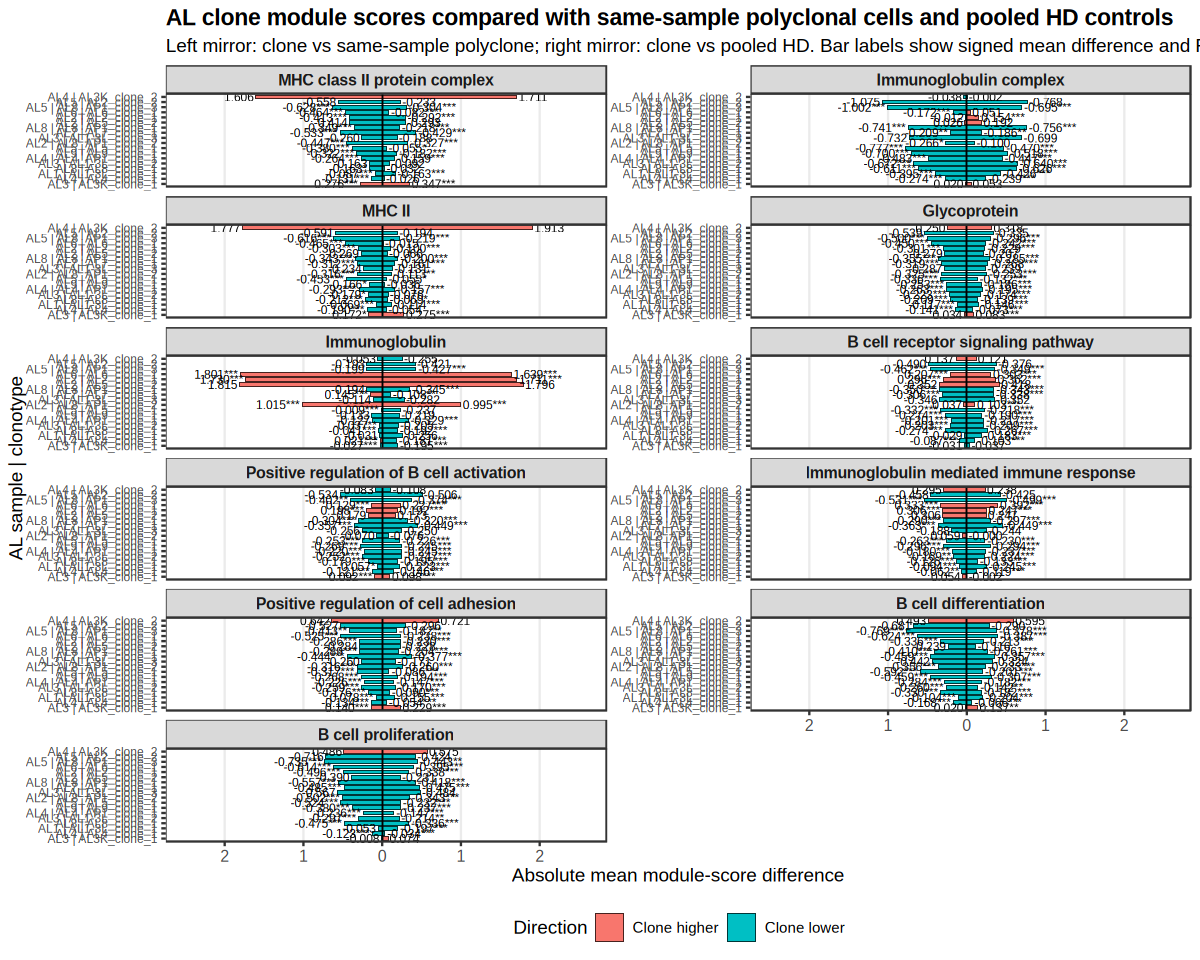

In [28]:
library(Seurat)
library(scCustomize)
library(dplyr)
library(tibble)
library(ggplot2)
library(patchwork)
library(scales)
library(tidyr)
library(stringr)
library(forcats)

# ============================================================
# 0) Input
# ============================================================

obj <- sce1_plasma_bcr

clone_col  <- "clonotype"
sample_col <- "donor_id_global"

enrich_path <- "enrichment.selected_dw-ALonly.tsv"

# Minimum cells required for statistical comparison
min_cells_clone <- 5
min_cells_poly  <- 5
min_cells_HD    <- 20

# Define which clonotype labels should be treated as polyclonal.
# Adjust this if your polyclonal cells use a different label.
polyclone_patterns <- c(
  "^polyclon",
  "^poly$",
  "^polyclonal$",
  "^polyclone$",
  "^nonclonal$",
  "^non_clonal$",
  "^unassigned$",
  "^none$",
  "^na$",
  "^nan$",
  "^unknown$"
)

# ============================================================
# 1) Robust assay selection
# ============================================================

if (!inherits(obj, "Seurat")) {
  stop(
    "obj is not a Seurat object. Current class is: ",
    paste(class(obj), collapse = ", ")
  )
}

assay_names <- names(obj@assays)

message("Available assays: ", paste(assay_names, collapse = ", "))

assay_to_use <- if ("RNA" %in% assay_names) {
  "RNA"
} else {
  DefaultAssay(obj)
}

DefaultAssay(obj) <- assay_to_use

message("Using assay: ", assay_to_use)

# ============================================================
# 2) Split samples BEFORE processing: AL vs HD
# ============================================================

if (!sample_col %in% colnames(obj@meta.data)) {
  stop("sample_col not found in obj@meta.data: ", sample_col)
}

if (!clone_col %in% colnames(obj@meta.data)) {
  stop("clone_col not found in obj@meta.data: ", clone_col)
}

obj$sample_id_for_analysis <- as.character(obj@meta.data[[sample_col]])

obj$sample_group_for_analysis <- case_when(
  str_detect(obj$sample_id_for_analysis, "^AL") ~ "AL",
  str_detect(obj$sample_id_for_analysis, "^HD") ~ "HD",
  TRUE ~ "Other"
)

message("Sample-group cell counts before subsetting:")
print(table(obj$sample_group_for_analysis, useNA = "ifany"))

# Keep only AL and HD samples
obj <- subset(
  obj,
  subset = sample_group_for_analysis %in% c("AL", "HD")
)

message("Sample-group cell counts after subsetting:")
print(table(obj$sample_group_for_analysis, useNA = "ifany"))

message("Samples retained:")
print(sort(unique(obj$sample_id_for_analysis)))

# ============================================================
# 3) Define clone status: clone vs polyclone
# ============================================================

is_poly_label <- function(x) {
  x <- as.character(x)
  x_clean <- str_to_lower(trimws(x))

  out <- is.na(x_clean) | x_clean == ""

  for (pat in polyclone_patterns) {
    out <- out | str_detect(x_clean, pat)
  }

  out
}

obj$clone_id_for_analysis <- as.character(obj@meta.data[[clone_col]])

obj$clone_status_for_analysis <- ifelse(
  is_poly_label(obj$clone_id_for_analysis),
  "polyclone",
  "clone"
)

message("Clone-status cell counts:")
print(table(
  obj$sample_group_for_analysis,
  obj$clone_status_for_analysis,
  useNA = "ifany"
))

# Check AL sample-level clone/polyclone counts
al_clone_status_check <- obj@meta.data %>%
  as_tibble(rownames = "cell") %>%
  filter(sample_group_for_analysis == "AL") %>%
  count(sample_id_for_analysis, clone_status_for_analysis) %>%
  arrange(sample_id_for_analysis, clone_status_for_analysis)

print(al_clone_status_check)

write.csv(
  al_clone_status_check,
  "AL_sample_clone_polyclone_cell_counts.csv",
  row.names = FALSE
)

# ============================================================
# 4) Read enrichment table and parse genes from last column
# ============================================================

enrich_tbl <- read.delim(
  enrich_path,
  sep = "\t",
  header = TRUE,
  check.names = FALSE,
  stringsAsFactors = FALSE
)

gene_col <- tail(colnames(enrich_tbl), 1)
message("Parsing genes from last column: ", gene_col)

parse_gene_string <- function(x) {
  genes <- unlist(strsplit(as.character(x), split = "[,;]"))
  genes <- trimws(genes)
  genes <- genes[genes != "" & !is.na(genes)]
  unique(genes)
}

make_safe_name <- function(x) {
  x <- gsub("[^A-Za-z0-9]+", "_", x)
  x <- gsub("^_+|_+$", "", x)
  x <- substr(x, 1, 60)
  x
}

gene_sets_raw <- lapply(enrich_tbl[[gene_col]], parse_gene_string)

term_desc <- enrich_tbl[["term description"]]
term_id   <- enrich_tbl[["term ID"]]

score_cols <- paste0(
  "score_",
  make_safe_name(term_desc),
  "_",
  make_safe_name(term_id)
)

names(gene_sets_raw) <- score_cols

# ============================================================
# 5) Match parsed genes to genes present in Seurat object
# ============================================================

obj_genes <- rownames(obj)

gene_map <- obj_genes
names(gene_map) <- toupper(obj_genes)
gene_map <- gene_map[!duplicated(names(gene_map))]

match_genes_to_obj <- function(genes) {
  matched <- gene_map[toupper(genes)]
  matched <- unname(matched)
  matched <- matched[!is.na(matched)]
  unique(matched)
}

gene_sets_present <- lapply(gene_sets_raw, match_genes_to_obj)

score_report <- tibble(
  score_col = score_cols,
  term_id = term_id,
  term_description = term_desc,
  n_genes_input = lengths(gene_sets_raw),
  n_genes_found = lengths(gene_sets_present),
  genes_input = sapply(gene_sets_raw, paste, collapse = ","),
  genes_used = sapply(gene_sets_present, paste, collapse = ","),
  missing_genes = mapply(
    function(input, used) {
      missing <- setdiff(toupper(input), toupper(used))
      paste(missing, collapse = ",")
    },
    gene_sets_raw,
    gene_sets_present
  )
)

write.csv(
  score_report,
  "enrichment_module_score_gene_matching_report.csv",
  row.names = FALSE
)

print(score_report %>% select(term_description, n_genes_input, n_genes_found))

# ============================================================
# 6) Add module scores one by one
# ============================================================

min_genes <- 1
scored_cols <- c()

for (i in seq_along(gene_sets_present)) {
  gs <- gene_sets_present[[i]]
  score_col <- score_cols[i]

  if (length(gs) < min_genes) {
    message("Skipping ", score_col, ": no genes found in object.")
    next
  }

  tmp_prefix <- paste0(score_col, "_tmp")

  obj <- AddModuleScore(
    object = obj,
    features = list(gs),
    name = tmp_prefix,
    assay = assay_to_use,
    search = FALSE
  )

  created_col <- paste0(tmp_prefix, "1")

  obj[[score_col]] <- obj@meta.data[[created_col]]
  obj[[created_col]] <- NULL

  scored_cols <- c(scored_cols, score_col)

  message("Scored: ", score_col, " using ", length(gs), " genes.")
}

sce1_plasma_bcr_AL_HD_scored <- obj

# ============================================================
# 7) Long-format score table
# ============================================================

score_long <- obj@meta.data %>%
  rownames_to_column("cell") %>%
  select(
    cell,
    all_of(sample_col),
    all_of(clone_col),
    sample_id_for_analysis,
    sample_group_for_analysis,
    clone_id_for_analysis,
    clone_status_for_analysis,
    all_of(scored_cols)
  ) %>%
  pivot_longer(
    cols = all_of(scored_cols),
    names_to = "score_col",
    values_to = "score"
  ) %>%
  left_join(
    score_report %>% select(score_col, term_id, term_description),
    by = "score_col"
  )

write.csv(
  score_long,
  "enrichment_module_scores_long_AL_HD_only.csv",
  row.names = FALSE
)

# ============================================================
# 8) Helper functions for comparison
# ============================================================

safe_wilcox <- function(x, y, min_x = 5, min_y = 5) {
  x <- x[!is.na(x)]
  y <- y[!is.na(y)]

  if (length(x) < min_x || length(y) < min_y) {
    return(NA_real_)
  }

  out <- tryCatch(
    wilcox.test(x, y)$p.value,
    error = function(e) NA_real_
  )

  out
}

calc_comparison_stats <- function(clone_scores, ref_scores, min_clone, min_ref) {
  clone_scores <- clone_scores[!is.na(clone_scores)]
  ref_scores <- ref_scores[!is.na(ref_scores)]

  tibble(
    n_clone = length(clone_scores),
    n_ref = length(ref_scores),
    clone_mean = mean(clone_scores, na.rm = TRUE),
    ref_mean = mean(ref_scores, na.rm = TRUE),
    mean_diff = mean(clone_scores, na.rm = TRUE) - mean(ref_scores, na.rm = TRUE),
    clone_median = median(clone_scores, na.rm = TRUE),
    ref_median = median(ref_scores, na.rm = TRUE),
    median_diff = median(clone_scores, na.rm = TRUE) - median(ref_scores, na.rm = TRUE),
    p_value = safe_wilcox(
      clone_scores,
      ref_scores,
      min_x = min_clone,
      min_y = min_ref
    )
  )
}

# ============================================================
# 9) Build clone distributions for AL samples
# ============================================================

# AL clone cells only
al_clone_dist <- score_long %>%
  filter(
    sample_group_for_analysis == "AL",
    clone_status_for_analysis == "clone",
    !is.na(score)
  ) %>%
  group_by(
    sample_id_for_analysis,
    clone_id_for_analysis,
    score_col,
    term_id,
    term_description
  ) %>%
  summarise(
    clone_scores = list(score),
    n_clone_raw = n(),
    .groups = "drop"
  )

# AL same-sample polyclonal reference
al_poly_ref <- score_long %>%
  filter(
    sample_group_for_analysis == "AL",
    clone_status_for_analysis == "polyclone",
    !is.na(score)
  ) %>%
  group_by(
    sample_id_for_analysis,
    score_col,
    term_id,
    term_description
  ) %>%
  summarise(
    poly_scores = list(score),
    n_poly_raw = n(),
    .groups = "drop"
  )

# Pooled HD reference
hd_pooled_ref <- score_long %>%
  filter(
    sample_group_for_analysis == "HD",
    !is.na(score)
  ) %>%
  group_by(
    score_col,
    term_id,
    term_description
  ) %>%
  summarise(
    hd_scores = list(score),
    n_HD_raw = n(),
    .groups = "drop"
  )

message("Pooled HD cells used as reference:")
print(
  score_long %>%
    filter(sample_group_for_analysis == "HD") %>%
    distinct(cell, sample_id_for_analysis) %>%
    count(sample_id_for_analysis, name = "n_cells") %>%
    arrange(sample_id_for_analysis)
)

# ============================================================
# 10) Comparison 1: AL clone vs same-sample AL polyclone
# ============================================================

clone_vs_poly <- al_clone_dist %>%
  left_join(
    al_poly_ref,
    by = c(
      "sample_id_for_analysis",
      "score_col",
      "term_id",
      "term_description"
    )
  ) %>%
  rowwise() %>%
  mutate(
    stats = list(
      calc_comparison_stats(
        clone_scores = unlist(clone_scores),
        ref_scores = unlist(poly_scores),
        min_clone = min_cells_clone,
        min_ref = min_cells_poly
      )
    )
  ) %>%
  ungroup() %>%
  select(
    sample_id_for_analysis,
    clone_id_for_analysis,
    score_col,
    term_id,
    term_description,
    stats
  ) %>%
  unnest(stats) %>%
  mutate(
    comparison = "clone_vs_same_sample_polyclone",
    reference = "same_sample_polyclone"
  )

# ============================================================
# 11) Comparison 2: AL clone vs pooled HD
# ============================================================

clone_vs_HD <- al_clone_dist %>%
  left_join(
    hd_pooled_ref,
    by = c(
      "score_col",
      "term_id",
      "term_description"
    )
  ) %>%
  rowwise() %>%
  mutate(
    stats = list(
      calc_comparison_stats(
        clone_scores = unlist(clone_scores),
        ref_scores = unlist(hd_scores),
        min_clone = min_cells_clone,
        min_ref = min_cells_HD
      )
    )
  ) %>%
  ungroup() %>%
  select(
    sample_id_for_analysis,
    clone_id_for_analysis,
    score_col,
    term_id,
    term_description,
    stats
  ) %>%
  unnest(stats) %>%
  mutate(
    comparison = "clone_vs_pooled_HD",
    reference = "pooled_HD"
  )

# ============================================================
# 12) Combine comparisons and adjust FDR
# ============================================================

clone_comparison_all <- bind_rows(
  clone_vs_poly,
  clone_vs_HD
) %>%
  group_by(comparison) %>%
  mutate(
    FDR = p.adjust(p_value, method = "BH")
  ) %>%
  ungroup() %>%
  mutate(
    direction = case_when(
      is.na(mean_diff) ~ NA_character_,
      mean_diff > 0 ~ "clone_higher",
      mean_diff < 0 ~ "clone_lower",
      TRUE ~ "no_difference"
    ),
    sig_label = case_when(
      is.na(FDR) ~ "",
      FDR < 0.001 ~ "***",
      FDR < 0.01 ~ "**",
      FDR < 0.05 ~ "*",
      TRUE ~ ""
    ),
    sample_clone = paste(sample_id_for_analysis, clone_id_for_analysis, sep = " | ")
  )

write.csv(
  clone_comparison_all,
  "AL_clone_module_score_comparisons_vs_poly_and_pooled_HD.csv",
  row.names = FALSE
)

# ============================================================
# 13) Mirror barplot data
# Left side  = clone vs same-sample polyclone
# Right side = clone vs pooled HD
# ============================================================

mirror_df <- clone_comparison_all %>%
  mutate(
    mirror_side = case_when(
      comparison == "clone_vs_same_sample_polyclone" ~ "Left: clone vs polyclone",
      comparison == "clone_vs_pooled_HD" ~ "Right: clone vs pooled HD",
      TRUE ~ comparison
    ),
    abs_mean_diff = abs(mean_diff),
    plot_value = case_when(
      comparison == "clone_vs_same_sample_polyclone" ~ -abs_mean_diff,
      comparison == "clone_vs_pooled_HD" ~ abs_mean_diff,
      TRUE ~ NA_real_
    ),
    plot_label = ifelse(
      is.na(mean_diff),
      "",
      paste0(
        sprintf("%.3f", mean_diff),
        sig_label
      )
    ),
    direction_label = case_when(
      direction == "clone_higher" ~ "Clone higher",
      direction == "clone_lower" ~ "Clone lower",
      direction == "no_difference" ~ "No difference",
      TRUE ~ "Not tested"
    )
  )

write.csv(
  mirror_df,
  "AL_clone_module_score_mirror_barplot_data.csv",
  row.names = FALSE
)

# Keep sample-clone order stable by average absolute effect size
sample_clone_order <- mirror_df %>%
  group_by(sample_clone) %>%
  summarise(
    mean_abs_effect = mean(abs_mean_diff, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(mean_abs_effect) %>%
  pull(sample_clone)

mirror_df <- mirror_df %>%
  mutate(
    sample_clone = factor(sample_clone, levels = sample_clone_order),
    term_description = factor(term_description, levels = unique(score_report$term_description))
  )

# ============================================================
# 14) One combined mirror barplot for all gene programs
# ============================================================

p_mirror_all <- mirror_df %>%
  ggplot(
    aes(
      x = plot_value,
      y = sample_clone,
      fill = direction_label
    )
  ) +
  geom_col(width = 0.75, color = "black", linewidth = 0.15) +
  geom_vline(xintercept = 0, linewidth = 0.4) +
  geom_text(
    aes(
      label = plot_label,
      hjust = ifelse(plot_value < 0, 1.05, -0.05)
    ),
    size = 2.4
  ) +
  facet_wrap(
    ~ term_description,
    scales = "free_y",
    ncol = 2
  ) +
  scale_x_continuous(
    labels = function(x) abs(x),
    expand = expansion(mult = c(0.25, 0.25))
  ) +
  labs(
    x = "Absolute mean module-score difference",
    y = "AL sample | clonotype",
    fill = "Direction",
    title = "AL clone module scores compared with same-sample polyclonal cells and pooled HD controls",
    subtitle = "Left mirror: clone vs same-sample polyclone; right mirror: clone vs pooled HD. Bar labels show signed mean difference and FDR significance."
  ) +
  theme_bw(base_size = 11) +
  theme(
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank(),
    strip.text = element_text(size = 9, face = "bold"),
    axis.text.y = element_text(size = 7),
    axis.text.x = element_text(size = 9),
    plot.title = element_text(face = "bold"),
    legend.position = "bottom"
  )

ggsave(
  "AL_clone_module_score_mirror_barplot_all_terms.pdf",
  p_mirror_all,
  width = 18,
  height = max(8, 0.25 * length(unique(mirror_df$sample_clone)) * ceiling(length(unique(mirror_df$term_description)) / 2))
)

p_mirror_all

# ============================================================
# 15) Save one mirror barplot per gene program
# ============================================================

out_dir <- "AL_clone_module_score_mirror_barplots_by_term"
dir.create(out_dir, showWarnings = FALSE)

for (this_score in unique(mirror_df$score_col)) {
  df_sub <- mirror_df %>%
    filter(score_col == this_score) %>%
    mutate(
      sample_clone = fct_reorder(sample_clone, abs_mean_diff, .fun = mean, na.rm = TRUE)
    )

  this_title <- unique(df_sub$term_description)
  this_title <- this_title[1]

  p_sub <- df_sub %>%
    ggplot(
      aes(
        x = plot_value,
        y = sample_clone,
        fill = direction_label
      )
    ) +
    geom_col(width = 0.75, color = "black", linewidth = 0.15) +
    geom_vline(xintercept = 0, linewidth = 0.4) +
    geom_text(
      aes(
        label = plot_label,
        hjust = ifelse(plot_value < 0, 1.05, -0.05)
      ),
      size = 2.8
    ) +
    scale_x_continuous(
      labels = function(x) abs(x),
      expand = expansion(mult = c(0.25, 0.25))
    ) +
    labs(
      x = "Absolute mean module-score difference",
      y = "AL sample | clonotype",
      fill = "Direction",
      title = this_title,
      subtitle = "Left: clone vs same-sample polyclone; right: clone vs pooled HD. Labels show signed mean difference and FDR significance."
    ) +
    theme_bw(base_size = 11) +
    theme(
      panel.grid.major.y = element_blank(),
      panel.grid.minor = element_blank(),
      plot.title = element_text(face = "bold"),
      legend.position = "bottom"
    )

  ggsave(
    filename = file.path(
      out_dir,
      paste0(this_score, "_mirror_barplot.pdf")
    ),
    plot = p_sub,
    width = 12,
    height = max(5, 0.3 * length(unique(df_sub$sample_clone)))
  )
}

# ============================================================
# 16) Optional: compact summary table
# ============================================================

summary_table <- clone_comparison_all %>%
  select(
    sample_id_for_analysis,
    clone_id_for_analysis,
    comparison,
    term_id,
    term_description,
    n_clone,
    n_ref,
    clone_mean,
    ref_mean,
    mean_diff,
    clone_median,
    ref_median,
    median_diff,
    p_value,
    FDR,
    direction
  ) %>%
  arrange(
    sample_id_for_analysis,
    clone_id_for_analysis,
    term_description,
    comparison
  )

write.csv(
  summary_table,
  "AL_clone_module_score_comparison_summary_table.csv",
  row.names = FALSE
)

head(summary_table)

## 7. Packages and setup


Available assays: RNA

Using assay: RNA

Sample-group cell counts before subsetting:




   AL    HD Other 
 2572  5109  1108 


Sample-group cell counts after subsetting:




  AL   HD 
2572 5109 


Samples retained:



...

Parsing genes from last column: matching proteins in your network (labels)



# A tibble: 12 × 3
   term_description                   n_genes_input n_genes_found
   <chr>                                      <int>         <int>
 1 MHC class I protein complex                    5             5
 2 Amyloidosis                                    5             5
 3 MHC I                                          5             5
 4 Amyloid                                        3             3
 5 Amyloidosis                                    3             3
 6 Cytoplasmic translation                       23            23
 7 Macromolecule biosynthetic process            30            30
 8 Ribosomal small subunit assembly               6             6
 9 Peptide chain elongation                      25            25
10 Cellular responses to stress                  31            31
11 Amyloid fiber formation                        5             5
12 Cyclin D associated events in G1               4             4


Scored: score_MHC_class_I_protein_complex_GO_0042612 using 5 genes.

Scored: score_Amyloidosis_DOID_9120 using 5 genes.

Scored: score_MHC_I_KW_0490 using 5 genes.

Scored: score_Amyloid_KW_0034 using 3 genes.

Scored: score_Amyloidosis_KW_1008 using 3 genes.

Scored: score_Cytoplasmic_translation_GO_0002181 using 23 genes.

Scored: score_Macromolecule_biosynthetic_process_GO_0009059 using 30 genes.

Scored: score_Ribosomal_small_subunit_assembly_GO_0000028 using 6 genes.

Scored: score_Peptide_chain_elongation_HSA_156902 using 25 genes.

Scored: score_Cellular_responses_to_stress_HSA_2262752 using 31 genes.

Scored: score_Amyloid_fiber_formation_HSA_977225 using 5 genes.

Scored: score_Cyclin_D_associated_events_in_G1_HSA_69231 using 4 genes.

Pooled HD cells used as reference:



# A tibble: 8 × 2
  sample_id_for_analysis n_cells
  <chr>                    <int>
1 HD1                        433
2 HD2                         36
3 HD3                        266
4 HD4                       1002
5 HD5                        725
6 HD6                        559
7 HD7                        839
8 HD8                       1249


sample_id_for_analysis,clone_id_for_analysis,comparison,term_id,term_description,n_clone,n_ref,clone_mean,ref_mean,mean_diff,clone_median,ref_median,median_diff,p_value,FDR,direction
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
AL1,AL1-3L_clone_1,clone_vs_pooled_HD,KW-0034,Amyloid,89,5109,1.699312,1.322831,0.37648093,1.707854,1.251537,0.45631764,6.221449e-13,1.431785e-12,clone_higher
AL1,AL1-3L_clone_1,clone_vs_same_sample_polyclone,KW-0034,Amyloid,89,95,1.699312,1.499869,0.19944327,1.707854,1.498730,0.20912476,5.901974e-03,7.869299e-03,clone_higher
AL1,AL1-3L_clone_1,clone_vs_pooled_HD,HSA-977225,Amyloid fiber formation,89,5109,1.347406,1.212447,0.13495834,1.367944,1.179238,0.18870594,4.776727e-05,7.165091e-05,clone_higher
AL1,AL1-3L_clone_1,clone_vs_same_sample_polyclone,HSA-977225,Amyloid fiber formation,89,95,1.347406,1.318496,0.02890969,1.367944,1.315002,0.05294209,6.900032e-01,7.527307e-01,clone_higher
AL1,AL1-3L_clone_1,clone_vs_pooled_HD,DOID:9120,Amyloidosis,89,5109,1.566113,1.379008,0.18710479,1.545368,1.361619,0.18374876,2.074940e-07,3.485898e-07,clone_higher
AL1,AL1-3L_clone_1,clone_vs_pooled_HD,KW-1008,Amyloidosis,89,5109,1.699312,1.322831,0.37648093,1.707854,1.251537,0.45631764,6.221449e-13,1.431785e-12,clone_higher


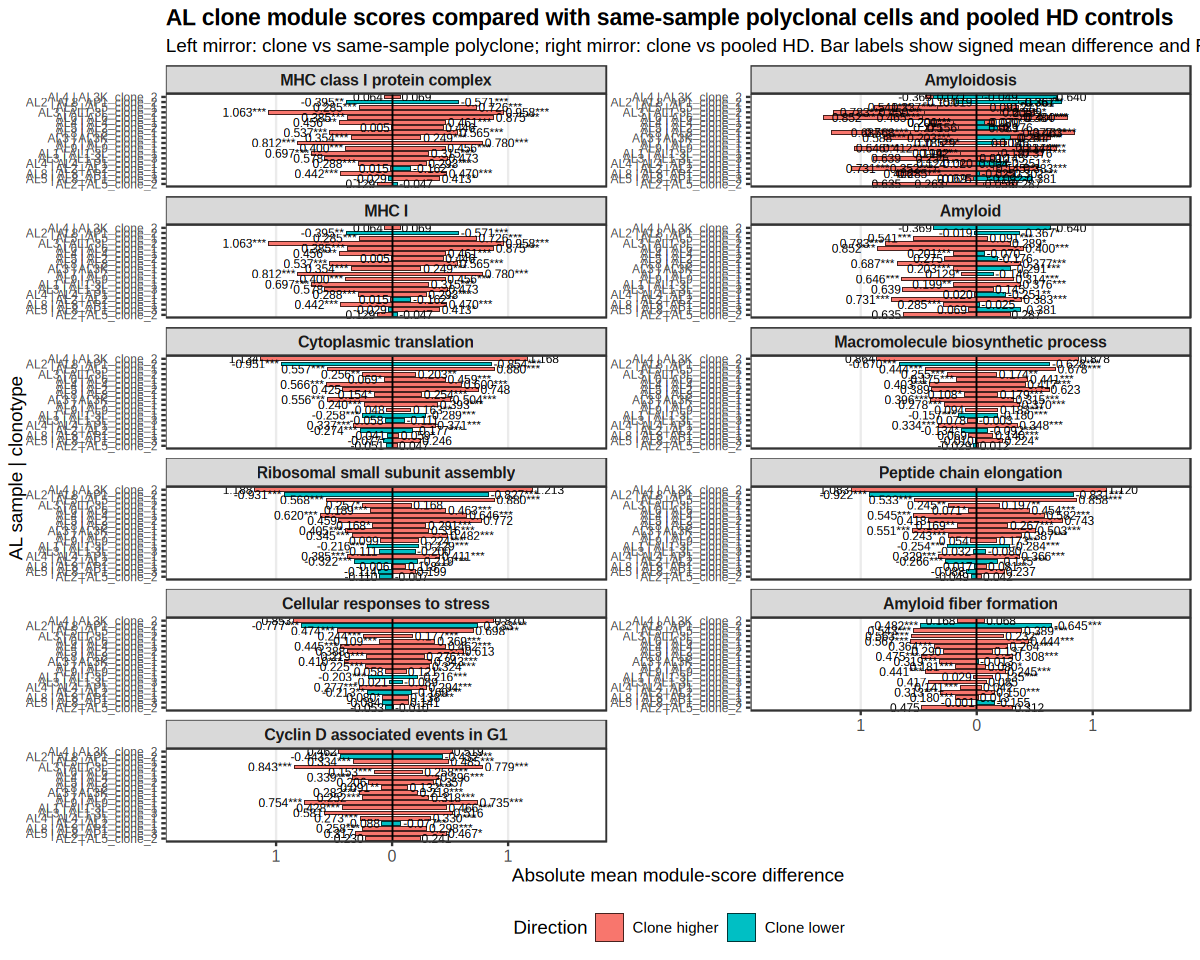

In [29]:
library(Seurat)
library(scCustomize)
library(dplyr)
library(tibble)
library(ggplot2)
library(patchwork)
library(scales)
library(tidyr)
library(stringr)
library(forcats)

# ============================================================
# 0) Input
# ============================================================

obj <- sce1_plasma_bcr

clone_col  <- "clonotype"
sample_col <- "donor_id_global"

enrich_path <- "enrichment.selected_up-ALonly.tsv"

# Minimum cells required for statistical comparison
min_cells_clone <- 5
min_cells_poly  <- 5
min_cells_HD    <- 20

# Define which clonotype labels should be treated as polyclonal.
# Adjust this if your polyclonal cells use a different label.
polyclone_patterns <- c(
  "^polyclon",
  "^poly$",
  "^polyclonal$",
  "^polyclone$",
  "^nonclonal$",
  "^non_clonal$",
  "^unassigned$",
  "^none$",
  "^na$",
  "^nan$",
  "^unknown$"
)

# ============================================================
# 1) Robust assay selection
# ============================================================

if (!inherits(obj, "Seurat")) {
  stop(
    "obj is not a Seurat object. Current class is: ",
    paste(class(obj), collapse = ", ")
  )
}

assay_names <- names(obj@assays)

message("Available assays: ", paste(assay_names, collapse = ", "))

assay_to_use <- if ("RNA" %in% assay_names) {
  "RNA"
} else {
  DefaultAssay(obj)
}

DefaultAssay(obj) <- assay_to_use

message("Using assay: ", assay_to_use)

# ============================================================
# 2) Split samples BEFORE processing: AL vs HD
# ============================================================

if (!sample_col %in% colnames(obj@meta.data)) {
  stop("sample_col not found in obj@meta.data: ", sample_col)
}

if (!clone_col %in% colnames(obj@meta.data)) {
  stop("clone_col not found in obj@meta.data: ", clone_col)
}

obj$sample_id_for_analysis <- as.character(obj@meta.data[[sample_col]])

obj$sample_group_for_analysis <- case_when(
  str_detect(obj$sample_id_for_analysis, "^AL") ~ "AL",
  str_detect(obj$sample_id_for_analysis, "^HD") ~ "HD",
  TRUE ~ "Other"
)

message("Sample-group cell counts before subsetting:")
print(table(obj$sample_group_for_analysis, useNA = "ifany"))

# Keep only AL and HD samples
obj <- subset(
  obj,
  subset = sample_group_for_analysis %in% c("AL", "HD")
)

message("Sample-group cell counts after subsetting:")
print(table(obj$sample_group_for_analysis, useNA = "ifany"))

message("Samples retained:")
print(sort(unique(obj$sample_id_for_analysis)))

# ============================================================
# 3) Define clone status: clone vs polyclone
# ============================================================

is_poly_label <- function(x) {
  x <- as.character(x)
  x_clean <- str_to_lower(trimws(x))

  out <- is.na(x_clean) | x_clean == ""

  for (pat in polyclone_patterns) {
    out <- out | str_detect(x_clean, pat)
  }

  out
}

obj$clone_id_for_analysis <- as.character(obj@meta.data[[clone_col]])

obj$clone_status_for_analysis <- ifelse(
  is_poly_label(obj$clone_id_for_analysis),
  "polyclone",
  "clone"
)

message("Clone-status cell counts:")
print(table(
  obj$sample_group_for_analysis,
  obj$clone_status_for_analysis,
  useNA = "ifany"
))

# Check AL sample-level clone/polyclone counts
al_clone_status_check <- obj@meta.data %>%
  as_tibble(rownames = "cell") %>%
  filter(sample_group_for_analysis == "AL") %>%
  count(sample_id_for_analysis, clone_status_for_analysis) %>%
  arrange(sample_id_for_analysis, clone_status_for_analysis)

print(al_clone_status_check)

write.csv(
  al_clone_status_check,
  "AL_sample_clone_polyclone_cell_counts.csv",
  row.names = FALSE
)

# ============================================================
# 4) Read enrichment table and parse genes from last column
# ============================================================

enrich_tbl <- read.delim(
  enrich_path,
  sep = "\t",
  header = TRUE,
  check.names = FALSE,
  stringsAsFactors = FALSE
)

gene_col <- tail(colnames(enrich_tbl), 1)
message("Parsing genes from last column: ", gene_col)

parse_gene_string <- function(x) {
  genes <- unlist(strsplit(as.character(x), split = "[,;]"))
  genes <- trimws(genes)
  genes <- genes[genes != "" & !is.na(genes)]
  unique(genes)
}

make_safe_name <- function(x) {
  x <- gsub("[^A-Za-z0-9]+", "_", x)
  x <- gsub("^_+|_+$", "", x)
  x <- substr(x, 1, 60)
  x
}

gene_sets_raw <- lapply(enrich_tbl[[gene_col]], parse_gene_string)

term_desc <- enrich_tbl[["term description"]]
term_id   <- enrich_tbl[["term ID"]]

score_cols <- paste0(
  "score_",
  make_safe_name(term_desc),
  "_",
  make_safe_name(term_id)
)

names(gene_sets_raw) <- score_cols

# ============================================================
# 5) Match parsed genes to genes present in Seurat object
# ============================================================

obj_genes <- rownames(obj)

gene_map <- obj_genes
names(gene_map) <- toupper(obj_genes)
gene_map <- gene_map[!duplicated(names(gene_map))]

match_genes_to_obj <- function(genes) {
  matched <- gene_map[toupper(genes)]
  matched <- unname(matched)
  matched <- matched[!is.na(matched)]
  unique(matched)
}

gene_sets_present <- lapply(gene_sets_raw, match_genes_to_obj)

score_report <- tibble(
  score_col = score_cols,
  term_id = term_id,
  term_description = term_desc,
  n_genes_input = lengths(gene_sets_raw),
  n_genes_found = lengths(gene_sets_present),
  genes_input = sapply(gene_sets_raw, paste, collapse = ","),
  genes_used = sapply(gene_sets_present, paste, collapse = ","),
  missing_genes = mapply(
    function(input, used) {
      missing <- setdiff(toupper(input), toupper(used))
      paste(missing, collapse = ",")
    },
    gene_sets_raw,
    gene_sets_present
  )
)

write.csv(
  score_report,
  "enrichment_module_score_gene_matching_report.csv",
  row.names = FALSE
)

print(score_report %>% select(term_description, n_genes_input, n_genes_found))

# ============================================================
# 6) Add module scores one by one
# ============================================================

min_genes <- 1
scored_cols <- c()

for (i in seq_along(gene_sets_present)) {
  gs <- gene_sets_present[[i]]
  score_col <- score_cols[i]

  if (length(gs) < min_genes) {
    message("Skipping ", score_col, ": no genes found in object.")
    next
  }

  tmp_prefix <- paste0(score_col, "_tmp")

  obj <- AddModuleScore(
    object = obj,
    features = list(gs),
    name = tmp_prefix,
    assay = assay_to_use,
    search = FALSE
  )

  created_col <- paste0(tmp_prefix, "1")

  obj[[score_col]] <- obj@meta.data[[created_col]]
  obj[[created_col]] <- NULL

  scored_cols <- c(scored_cols, score_col)

  message("Scored: ", score_col, " using ", length(gs), " genes.")
}

sce1_plasma_bcr_AL_HD_scored <- obj

# ============================================================
# 7) Long-format score table
# ============================================================

score_long <- obj@meta.data %>%
  rownames_to_column("cell") %>%
  select(
    cell,
    all_of(sample_col),
    all_of(clone_col),
    sample_id_for_analysis,
    sample_group_for_analysis,
    clone_id_for_analysis,
    clone_status_for_analysis,
    all_of(scored_cols)
  ) %>%
  pivot_longer(
    cols = all_of(scored_cols),
    names_to = "score_col",
    values_to = "score"
  ) %>%
  left_join(
    score_report %>% select(score_col, term_id, term_description),
    by = "score_col"
  )

write.csv(
  score_long,
  "enrichment_module_scores_long_AL_HD_only.csv",
  row.names = FALSE
)

# ============================================================
# 8) Helper functions for comparison
# ============================================================

safe_wilcox <- function(x, y, min_x = 5, min_y = 5) {
  x <- x[!is.na(x)]
  y <- y[!is.na(y)]

  if (length(x) < min_x || length(y) < min_y) {
    return(NA_real_)
  }

  out <- tryCatch(
    wilcox.test(x, y)$p.value,
    error = function(e) NA_real_
  )

  out
}

calc_comparison_stats <- function(clone_scores, ref_scores, min_clone, min_ref) {
  clone_scores <- clone_scores[!is.na(clone_scores)]
  ref_scores <- ref_scores[!is.na(ref_scores)]

  tibble(
    n_clone = length(clone_scores),
    n_ref = length(ref_scores),
    clone_mean = mean(clone_scores, na.rm = TRUE),
    ref_mean = mean(ref_scores, na.rm = TRUE),
    mean_diff = mean(clone_scores, na.rm = TRUE) - mean(ref_scores, na.rm = TRUE),
    clone_median = median(clone_scores, na.rm = TRUE),
    ref_median = median(ref_scores, na.rm = TRUE),
    median_diff = median(clone_scores, na.rm = TRUE) - median(ref_scores, na.rm = TRUE),
    p_value = safe_wilcox(
      clone_scores,
      ref_scores,
      min_x = min_clone,
      min_y = min_ref
    )
  )
}

# ============================================================
# 9) Build clone distributions for AL samples
# ============================================================

# AL clone cells only
al_clone_dist <- score_long %>%
  filter(
    sample_group_for_analysis == "AL",
    clone_status_for_analysis == "clone",
    !is.na(score)
  ) %>%
  group_by(
    sample_id_for_analysis,
    clone_id_for_analysis,
    score_col,
    term_id,
    term_description
  ) %>%
  summarise(
    clone_scores = list(score),
    n_clone_raw = n(),
    .groups = "drop"
  )

# AL same-sample polyclonal reference
al_poly_ref <- score_long %>%
  filter(
    sample_group_for_analysis == "AL",
    clone_status_for_analysis == "polyclone",
    !is.na(score)
  ) %>%
  group_by(
    sample_id_for_analysis,
    score_col,
    term_id,
    term_description
  ) %>%
  summarise(
    poly_scores = list(score),
    n_poly_raw = n(),
    .groups = "drop"
  )

# Pooled HD reference
hd_pooled_ref <- score_long %>%
  filter(
    sample_group_for_analysis == "HD",
    !is.na(score)
  ) %>%
  group_by(
    score_col,
    term_id,
    term_description
  ) %>%
  summarise(
    hd_scores = list(score),
    n_HD_raw = n(),
    .groups = "drop"
  )

message("Pooled HD cells used as reference:")
print(
  score_long %>%
    filter(sample_group_for_analysis == "HD") %>%
    distinct(cell, sample_id_for_analysis) %>%
    count(sample_id_for_analysis, name = "n_cells") %>%
    arrange(sample_id_for_analysis)
)

# ============================================================
# 10) Comparison 1: AL clone vs same-sample AL polyclone
# ============================================================

clone_vs_poly <- al_clone_dist %>%
  left_join(
    al_poly_ref,
    by = c(
      "sample_id_for_analysis",
      "score_col",
      "term_id",
      "term_description"
    )
  ) %>%
  rowwise() %>%
  mutate(
    stats = list(
      calc_comparison_stats(
        clone_scores = unlist(clone_scores),
        ref_scores = unlist(poly_scores),
        min_clone = min_cells_clone,
        min_ref = min_cells_poly
      )
    )
  ) %>%
  ungroup() %>%
  select(
    sample_id_for_analysis,
    clone_id_for_analysis,
    score_col,
    term_id,
    term_description,
    stats
  ) %>%
  unnest(stats) %>%
  mutate(
    comparison = "clone_vs_same_sample_polyclone",
    reference = "same_sample_polyclone"
  )

# ============================================================
# 11) Comparison 2: AL clone vs pooled HD
# ============================================================

clone_vs_HD <- al_clone_dist %>%
  left_join(
    hd_pooled_ref,
    by = c(
      "score_col",
      "term_id",
      "term_description"
    )
  ) %>%
  rowwise() %>%
  mutate(
    stats = list(
      calc_comparison_stats(
        clone_scores = unlist(clone_scores),
        ref_scores = unlist(hd_scores),
        min_clone = min_cells_clone,
        min_ref = min_cells_HD
      )
    )
  ) %>%
  ungroup() %>%
  select(
    sample_id_for_analysis,
    clone_id_for_analysis,
    score_col,
    term_id,
    term_description,
    stats
  ) %>%
  unnest(stats) %>%
  mutate(
    comparison = "clone_vs_pooled_HD",
    reference = "pooled_HD"
  )

# ============================================================
# 12) Combine comparisons and adjust FDR
# ============================================================

clone_comparison_all <- bind_rows(
  clone_vs_poly,
  clone_vs_HD
) %>%
  group_by(comparison) %>%
  mutate(
    FDR = p.adjust(p_value, method = "BH")
  ) %>%
  ungroup() %>%
  mutate(
    direction = case_when(
      is.na(mean_diff) ~ NA_character_,
      mean_diff > 0 ~ "clone_higher",
      mean_diff < 0 ~ "clone_lower",
      TRUE ~ "no_difference"
    ),
    sig_label = case_when(
      is.na(FDR) ~ "",
      FDR < 0.001 ~ "***",
      FDR < 0.01 ~ "**",
      FDR < 0.05 ~ "*",
      TRUE ~ ""
    ),
    sample_clone = paste(sample_id_for_analysis, clone_id_for_analysis, sep = " | ")
  )

write.csv(
  clone_comparison_all,
  "AL_clone_module_score_comparisons_vs_poly_and_pooled_HD.csv",
  row.names = FALSE
)

# ============================================================
# 13) Mirror barplot data
# Left side  = clone vs same-sample polyclone
# Right side = clone vs pooled HD
# ============================================================

mirror_df <- clone_comparison_all %>%
  mutate(
    mirror_side = case_when(
      comparison == "clone_vs_same_sample_polyclone" ~ "Left: clone vs polyclone",
      comparison == "clone_vs_pooled_HD" ~ "Right: clone vs pooled HD",
      TRUE ~ comparison
    ),
    abs_mean_diff = abs(mean_diff),
    plot_value = case_when(
      comparison == "clone_vs_same_sample_polyclone" ~ -abs_mean_diff,
      comparison == "clone_vs_pooled_HD" ~ abs_mean_diff,
      TRUE ~ NA_real_
    ),
    plot_label = ifelse(
      is.na(mean_diff),
      "",
      paste0(
        sprintf("%.3f", mean_diff),
        sig_label
      )
    ),
    direction_label = case_when(
      direction == "clone_higher" ~ "Clone higher",
      direction == "clone_lower" ~ "Clone lower",
      direction == "no_difference" ~ "No difference",
      TRUE ~ "Not tested"
    )
  )

write.csv(
  mirror_df,
  "AL_clone_module_score_mirror_barplot_data.csv",
  row.names = FALSE
)

# Keep sample-clone order stable by average absolute effect size
sample_clone_order <- mirror_df %>%
  group_by(sample_clone) %>%
  summarise(
    mean_abs_effect = mean(abs_mean_diff, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(mean_abs_effect) %>%
  pull(sample_clone)

mirror_df <- mirror_df %>%
  mutate(
    sample_clone = factor(sample_clone, levels = sample_clone_order),
    term_description = factor(term_description, levels = unique(score_report$term_description))
  )

# ============================================================
# 14) One combined mirror barplot for all gene programs
# ============================================================

p_mirror_all <- mirror_df %>%
  ggplot(
    aes(
      x = plot_value,
      y = sample_clone,
      fill = direction_label
    )
  ) +
  geom_col(width = 0.75, color = "black", linewidth = 0.15) +
  geom_vline(xintercept = 0, linewidth = 0.4) +
  geom_text(
    aes(
      label = plot_label,
      hjust = ifelse(plot_value < 0, 1.05, -0.05)
    ),
    size = 2.4
  ) +
  facet_wrap(
    ~ term_description,
    scales = "free_y",
    ncol = 2
  ) +
  scale_x_continuous(
    labels = function(x) abs(x),
    expand = expansion(mult = c(0.25, 0.25))
  ) +
  labs(
    x = "Absolute mean module-score difference",
    y = "AL sample | clonotype",
    fill = "Direction",
    title = "AL clone module scores compared with same-sample polyclonal cells and pooled HD controls",
    subtitle = "Left mirror: clone vs same-sample polyclone; right mirror: clone vs pooled HD. Bar labels show signed mean difference and FDR significance."
  ) +
  theme_bw(base_size = 11) +
  theme(
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank(),
    strip.text = element_text(size = 9, face = "bold"),
    axis.text.y = element_text(size = 7),
    axis.text.x = element_text(size = 9),
    plot.title = element_text(face = "bold"),
    legend.position = "bottom"
  )

ggsave(
  "AL_clone_module_score_mirror_barplot_all_terms.pdf",
  p_mirror_all,
  width = 18,
  height = max(8, 0.25 * length(unique(mirror_df$sample_clone)) * ceiling(length(unique(mirror_df$term_description)) / 2))
)

p_mirror_all

# ============================================================
# 15) Save one mirror barplot per gene program
# ============================================================

out_dir <- "AL_clone_module_score_mirror_barplots_by_term"
dir.create(out_dir, showWarnings = FALSE)

for (this_score in unique(mirror_df$score_col)) {
  df_sub <- mirror_df %>%
    filter(score_col == this_score) %>%
    mutate(
      sample_clone = fct_reorder(sample_clone, abs_mean_diff, .fun = mean, na.rm = TRUE)
    )

  this_title <- unique(df_sub$term_description)
  this_title <- this_title[1]

  p_sub <- df_sub %>%
    ggplot(
      aes(
        x = plot_value,
        y = sample_clone,
        fill = direction_label
      )
    ) +
    geom_col(width = 0.75, color = "black", linewidth = 0.15) +
    geom_vline(xintercept = 0, linewidth = 0.4) +
    geom_text(
      aes(
        label = plot_label,
        hjust = ifelse(plot_value < 0, 1.05, -0.05)
      ),
      size = 2.8
    ) +
    scale_x_continuous(
      labels = function(x) abs(x),
      expand = expansion(mult = c(0.25, 0.25))
    ) +
    labs(
      x = "Absolute mean module-score difference",
      y = "AL sample | clonotype",
      fill = "Direction",
      title = this_title,
      subtitle = "Left: clone vs same-sample polyclone; right: clone vs pooled HD. Labels show signed mean difference and FDR significance."
    ) +
    theme_bw(base_size = 11) +
    theme(
      panel.grid.major.y = element_blank(),
      panel.grid.minor = element_blank(),
      plot.title = element_text(face = "bold"),
      legend.position = "bottom"
    )

  ggsave(
    filename = file.path(
      out_dir,
      paste0(this_score, "_mirror_barplot.pdf")
    ),
    plot = p_sub,
    width = 12,
    height = max(5, 0.3 * length(unique(df_sub$sample_clone)))
  )
}

# ============================================================
# 16) Optional: compact summary table
# ============================================================

summary_table <- clone_comparison_all %>%
  select(
    sample_id_for_analysis,
    clone_id_for_analysis,
    comparison,
    term_id,
    term_description,
    n_clone,
    n_ref,
    clone_mean,
    ref_mean,
    mean_diff,
    clone_median,
    ref_median,
    median_diff,
    p_value,
    FDR,
    direction
  ) %>%
  arrange(
    sample_id_for_analysis,
    clone_id_for_analysis,
    term_description,
    comparison
  )

write.csv(
  summary_table,
  "AL_clone_module_score_comparison_summary_table.csv",
  row.names = FALSE
)

head(summary_table)

Available assays: RNA

Using assay: RNA

Sample-group cell counts before subsetting:




   AL    HD Other 
 2572  5109  1108 


Sample-group cell counts after subsetting:




  AL   HD 
2572 5109 


Clone-status cell counts:



    
     clone polyclone
  AL  1820       752
  HD     2      5107


Loaded enrichment terms:



# A tibble: 2 × 2
  regulation n_terms
  <chr>        <int>
1 dw              10
2 up              12
# A tibble: 22 × 4
   regulation term_description                   n_genes_input n_genes_found
   <chr>      <chr>                                      <int>         <int>
 1 up         MHC class I protein complex                    5             5
 2 up         Amyloidosis                                    5             5
 3 up         MHC I                                          5             5
 4 up         Amyloid                                        3             3
 5 up         Amyloidosis                                    3             3
 6 up         Cytoplasmic translation                       23            23
 7 up         Macromolecule biosynthetic process            30            30
 8 up         Ribosomal small subunit assembly               6             6
 9 up         Peptide chain elongation                      25            25
10 up         Cellular responses

Scored: up | MHC class I protein complex using 5 genes.

Scored: up | Amyloidosis using 5 genes.

Scored: up | MHC I using 5 genes.

Scored: up | Amyloid using 3 genes.

Scored: up | Amyloidosis using 3 genes.

Scored: up | Cytoplasmic translation using 23 genes.

Scored: up | Macromolecule biosynthetic process using 30 genes.

Scored: up | Ribosomal small subunit assembly using 6 genes.

Scored: up | Peptide chain elongation using 25 genes.

Scored: up | Cellular responses to stress using 31 genes.

Scored: up | Amyloid fiber formation using 5 genes.

Scored: up | Cyclin D associated events in G1 using 4 genes.

Scored: dw | MHC class II protein complex using 7 genes.

Scored: dw | Immunoglobulin complex using 7 genes.

Scored: dw | MHC II using 5 genes.

Scored: dw | Glycoprotein using 41 genes.

Scored: dw | B cell receptor signaling pathway using 9 genes.

Scored: dw | Positive regulation of B cell activation using 10 genes.

Scored: dw | Immunoglobulin mediated immune response usi

# A tibble: 8 × 2
  sample_id_for_analysis n_cells
  <chr>                    <int>
1 HD1                        433
2 HD2                         36
3 HD3                        266
4 HD4                       1002
5 HD5                        725
6 HD6                        559
7 HD7                        839
8 HD8                       1249


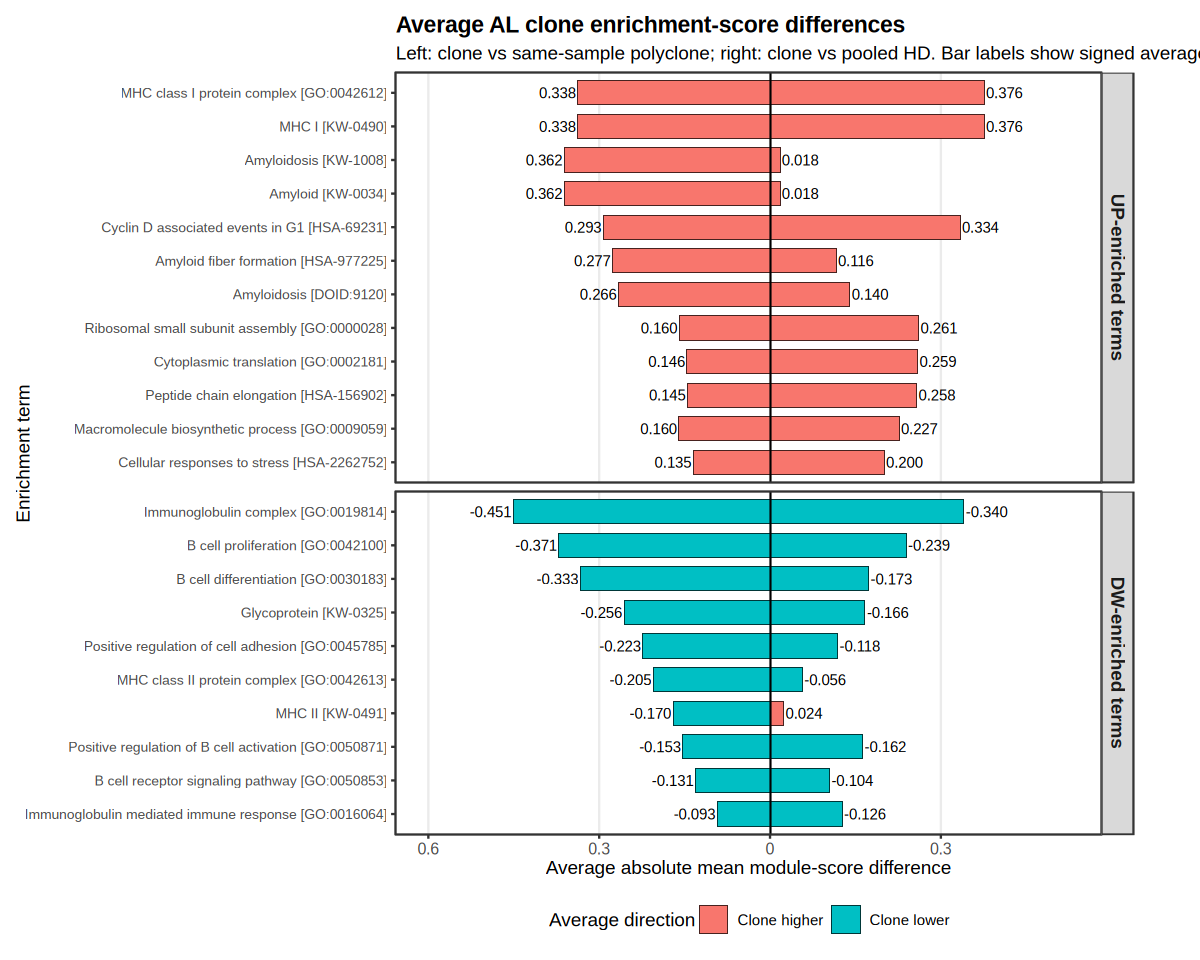

In [31]:
library(Seurat)
library(scCustomize)
library(dplyr)
library(tibble)
library(ggplot2)
library(patchwork)
library(scales)
library(tidyr)
library(stringr)
library(forcats)

# ============================================================
# 0) Input
# ============================================================

obj <- sce1_plasma_bcr

clone_col  <- "clonotype"
sample_col <- "donor_id_global"

enrich_paths <- c(
  up = "enrichment.selected_up-ALonly.tsv",
  dw = "enrichment.selected_dw-ALonly.tsv"
)

out_pdf <- "AL_enrichment_up_dw_average_mirror_barplot.pdf"

min_cells_clone <- 5
min_cells_poly  <- 5
min_cells_HD    <- 20

set.seed(1)

# ============================================================
# 1) Polyclone label definition
# ============================================================

polyclone_patterns <- c(
  "^polyclon",
  "^poly$",
  "^polyclonal$",
  "^polyclone$",
  "^nonclonal$",
  "^non_clonal$",
  "^unassigned$",
  "^none$",
  "^na$",
  "^nan$",
  "^unknown$"
)

is_poly_label <- function(x) {
  x <- as.character(x)
  x_clean <- str_to_lower(trimws(x))

  out <- is.na(x_clean) | x_clean == ""

  for (pat in polyclone_patterns) {
    out <- out | str_detect(x_clean, pat)
  }

  out
}

# ============================================================
# 2) Robust assay selection
# ============================================================

if (!inherits(obj, "Seurat")) {
  stop(
    "obj is not a Seurat object. Current class is: ",
    paste(class(obj), collapse = ", ")
  )
}

if (!sample_col %in% colnames(obj@meta.data)) {
  stop("sample_col not found in obj@meta.data: ", sample_col)
}

if (!clone_col %in% colnames(obj@meta.data)) {
  stop("clone_col not found in obj@meta.data: ", clone_col)
}

assay_names <- names(obj@assays)
message("Available assays: ", paste(assay_names, collapse = ", "))

assay_to_use <- if ("RNA" %in% assay_names) {
  "RNA"
} else {
  DefaultAssay(obj)
}

DefaultAssay(obj) <- assay_to_use
message("Using assay: ", assay_to_use)

# ============================================================
# 3) Split AL and HD samples before scoring
# ============================================================

obj$sample_id_for_analysis <- as.character(obj@meta.data[[sample_col]])

obj$sample_group_for_analysis <- case_when(
  str_detect(obj$sample_id_for_analysis, "^AL") ~ "AL",
  str_detect(obj$sample_id_for_analysis, "^HD") ~ "HD",
  TRUE ~ "Other"
)

message("Sample-group cell counts before subsetting:")
print(table(obj$sample_group_for_analysis, useNA = "ifany"))

obj <- subset(
  obj,
  subset = sample_group_for_analysis %in% c("AL", "HD")
)

message("Sample-group cell counts after subsetting:")
print(table(obj$sample_group_for_analysis, useNA = "ifany"))

obj$clone_id_for_analysis <- as.character(obj@meta.data[[clone_col]])

obj$clone_status_for_analysis <- ifelse(
  is_poly_label(obj$clone_id_for_analysis),
  "polyclone",
  "clone"
)

message("Clone-status cell counts:")
print(table(
  obj$sample_group_for_analysis,
  obj$clone_status_for_analysis,
  useNA = "ifany"
))

write.csv(
  obj@meta.data %>%
    rownames_to_column("cell") %>%
    count(
      sample_group_for_analysis,
      sample_id_for_analysis,
      clone_status_for_analysis,
      name = "n_cells"
    ),
  "AL_HD_sample_clone_status_cell_counts.csv",
  row.names = FALSE
)

# ============================================================
# 4) Read UP and DW enrichment tables
# ============================================================

parse_gene_string <- function(x) {
  genes <- unlist(strsplit(as.character(x), split = "[,;]"))
  genes <- trimws(genes)
  genes <- genes[genes != "" & !is.na(genes)]
  unique(genes)
}

make_safe_name <- function(x) {
  x <- gsub("[^A-Za-z0-9]+", "_", x)
  x <- gsub("^_+|_+$", "", x)
  x <- substr(x, 1, 60)
  x
}

read_one_enrichment <- function(path, regulation) {
  if (!file.exists(path)) {
    stop("Cannot find enrichment file: ", path)
  }

  tbl <- read.delim(
    path,
    sep = "\t",
    header = TRUE,
    check.names = FALSE,
    stringsAsFactors = FALSE
  )

  gene_col <- tail(colnames(tbl), 1)

  term_desc <- if ("term description" %in% colnames(tbl)) {
    tbl[["term description"]]
  } else {
    tbl[[1]]
  }

  term_id <- if ("term ID" %in% colnames(tbl)) {
    tbl[["term ID"]]
  } else {
    paste0(regulation, "_term_", seq_len(nrow(tbl)))
  }

  out <- tibble(
    regulation = regulation,
    source_file = path,
    term_index = seq_len(nrow(tbl)),
    term_id = as.character(term_id),
    term_description = as.character(term_desc),
    raw_gene_string = as.character(tbl[[gene_col]])
  ) %>%
    mutate(
      score_col = paste0(
        "score_",
        regulation,
        "_",
        make_safe_name(term_description),
        "_",
        make_safe_name(term_id),
        "_",
        term_index
      ),
      gene_list_raw = lapply(raw_gene_string, parse_gene_string)
    )

  out
}

enrich_sets <- bind_rows(
  lapply(names(enrich_paths), function(x) {
    read_one_enrichment(enrich_paths[[x]], x)
  })
)

message("Loaded enrichment terms:")
print(enrich_sets %>% count(regulation, name = "n_terms"))

# ============================================================
# 5) Match genes to Seurat object
# ============================================================

obj_genes <- rownames(obj)

gene_map <- obj_genes
names(gene_map) <- toupper(obj_genes)
gene_map <- gene_map[!duplicated(names(gene_map))]

match_genes_to_obj <- function(genes) {
  matched <- gene_map[toupper(genes)]
  matched <- unname(matched)
  matched <- matched[!is.na(matched)]
  unique(matched)
}

enrich_sets <- enrich_sets %>%
  rowwise() %>%
  mutate(
    gene_list_present = list(match_genes_to_obj(unlist(gene_list_raw))),
    n_genes_input = length(unlist(gene_list_raw)),
    n_genes_found = length(unlist(gene_list_present)),
    genes_input = paste(unlist(gene_list_raw), collapse = ","),
    genes_used = paste(unlist(gene_list_present), collapse = ","),
    missing_genes = paste(
      setdiff(
        toupper(unlist(gene_list_raw)),
        toupper(unlist(gene_list_present))
      ),
      collapse = ","
    )
  ) %>%
  ungroup()

score_report <- enrich_sets %>%
  select(
    regulation,
    source_file,
    term_index,
    term_id,
    term_description,
    score_col,
    n_genes_input,
    n_genes_found,
    genes_input,
    genes_used,
    missing_genes
  )

write.csv(
  score_report,
  "up_dw_enrichment_module_score_gene_matching_report.csv",
  row.names = FALSE
)

print(score_report %>% select(regulation, term_description, n_genes_input, n_genes_found))

# ============================================================
# 6) Add module scores
# ============================================================

min_genes <- 1
scored_cols <- c()

for (i in seq_len(nrow(enrich_sets))) {
  gs <- enrich_sets$gene_list_present[[i]]
  score_col <- enrich_sets$score_col[[i]]

  if (length(gs) < min_genes) {
    message("Skipping ", score_col, ": no genes found in object.")
    next
  }

  tmp_prefix <- paste0(score_col, "_tmp")

  obj <- AddModuleScore(
    object = obj,
    features = list(gs),
    name = tmp_prefix,
    assay = assay_to_use,
    search = FALSE,
    seed = 1
  )

  created_col <- paste0(tmp_prefix, "1")

  obj[[score_col]] <- obj@meta.data[[created_col]]
  obj[[created_col]] <- NULL

  scored_cols <- c(scored_cols, score_col)

  message(
    "Scored: ",
    enrich_sets$regulation[[i]],
    " | ",
    enrich_sets$term_description[[i]],
    " using ",
    length(gs),
    " genes."
  )
}

sce1_plasma_bcr_AL_HD_up_dw_scored <- obj

# ============================================================
# 7) Long-format score table
# ============================================================

score_long <- obj@meta.data %>%
  rownames_to_column("cell") %>%
  select(
    cell,
    all_of(sample_col),
    all_of(clone_col),
    sample_id_for_analysis,
    sample_group_for_analysis,
    clone_id_for_analysis,
    clone_status_for_analysis,
    all_of(scored_cols)
  ) %>%
  pivot_longer(
    cols = all_of(scored_cols),
    names_to = "score_col",
    values_to = "score"
  ) %>%
  left_join(
    score_report %>%
      select(
        regulation,
        score_col,
        term_id,
        term_description
      ),
    by = "score_col"
  )

write.csv(
  score_long,
  "up_dw_enrichment_module_scores_long_AL_HD_only.csv",
  row.names = FALSE
)

# ============================================================
# 8) Statistical helper functions
# ============================================================

as_num_vec <- function(x) {
  y <- unlist(x, use.names = FALSE)
  y <- as.numeric(y)
  y <- y[!is.na(y)]
  y
}

safe_mean <- function(x) {
  x <- x[!is.na(x)]
  if (length(x) == 0) return(NA_real_)
  mean(x)
}

safe_median <- function(x) {
  x <- x[!is.na(x)]
  if (length(x) == 0) return(NA_real_)
  median(x)
}

safe_wilcox <- function(x, y, min_x = 5, min_y = 5) {
  x <- x[!is.na(x)]
  y <- y[!is.na(y)]

  if (length(x) < min_x || length(y) < min_y) {
    return(NA_real_)
  }

  tryCatch(
    wilcox.test(x, y)$p.value,
    error = function(e) NA_real_
  )
}

calc_comparison_stats <- function(clone_scores, ref_scores, min_clone, min_ref) {
  clone_scores <- as_num_vec(clone_scores)
  ref_scores   <- as_num_vec(ref_scores)

  tibble(
    n_clone = length(clone_scores),
    n_ref = length(ref_scores),
    clone_mean = safe_mean(clone_scores),
    ref_mean = safe_mean(ref_scores),
    mean_diff = safe_mean(clone_scores) - safe_mean(ref_scores),
    clone_median = safe_median(clone_scores),
    ref_median = safe_median(ref_scores),
    median_diff = safe_median(clone_scores) - safe_median(ref_scores),
    p_value = safe_wilcox(
      clone_scores,
      ref_scores,
      min_x = min_clone,
      min_y = min_ref
    )
  )
}

# ============================================================
# 9) Build AL clone, AL polyclone, and pooled HD references
# ============================================================

al_clone_dist <- score_long %>%
  filter(
    sample_group_for_analysis == "AL",
    clone_status_for_analysis == "clone",
    !is.na(score)
  ) %>%
  group_by(
    sample_id_for_analysis,
    clone_id_for_analysis,
    regulation,
    score_col,
    term_id,
    term_description
  ) %>%
  summarise(
    clone_scores = list(score),
    n_clone_raw = n(),
    .groups = "drop"
  )

al_poly_ref <- score_long %>%
  filter(
    sample_group_for_analysis == "AL",
    clone_status_for_analysis == "polyclone",
    !is.na(score)
  ) %>%
  group_by(
    sample_id_for_analysis,
    regulation,
    score_col,
    term_id,
    term_description
  ) %>%
  summarise(
    poly_scores = list(score),
    n_poly_raw = n(),
    .groups = "drop"
  )

hd_pooled_ref <- score_long %>%
  filter(
    sample_group_for_analysis == "HD",
    !is.na(score)
  ) %>%
  group_by(
    regulation,
    score_col,
    term_id,
    term_description
  ) %>%
  summarise(
    hd_scores = list(score),
    n_HD_raw = n(),
    .groups = "drop"
  )

message("Pooled HD cells used as control:")
print(
  score_long %>%
    filter(sample_group_for_analysis == "HD") %>%
    distinct(cell, sample_id_for_analysis) %>%
    count(sample_id_for_analysis, name = "n_cells") %>%
    arrange(sample_id_for_analysis)
)

# ============================================================
# 10) Clone vs same-sample polyclone
# ============================================================

clone_vs_poly <- al_clone_dist %>%
  left_join(
    al_poly_ref,
    by = c(
      "sample_id_for_analysis",
      "regulation",
      "score_col",
      "term_id",
      "term_description"
    )
  ) %>%
  rowwise() %>%
  mutate(
    stats = list(
      calc_comparison_stats(
        clone_scores = clone_scores,
        ref_scores = poly_scores,
        min_clone = min_cells_clone,
        min_ref = min_cells_poly
      )
    )
  ) %>%
  ungroup() %>%
  select(
    sample_id_for_analysis,
    clone_id_for_analysis,
    regulation,
    score_col,
    term_id,
    term_description,
    stats
  ) %>%
  unnest(stats) %>%
  mutate(
    comparison = "clone_vs_same_sample_polyclone",
    reference = "same_sample_polyclone"
  )

# ============================================================
# 11) Clone vs pooled HD
# ============================================================

clone_vs_HD <- al_clone_dist %>%
  left_join(
    hd_pooled_ref,
    by = c(
      "regulation",
      "score_col",
      "term_id",
      "term_description"
    )
  ) %>%
  rowwise() %>%
  mutate(
    stats = list(
      calc_comparison_stats(
        clone_scores = clone_scores,
        ref_scores = hd_scores,
        min_clone = min_cells_clone,
        min_ref = min_cells_HD
      )
    )
  ) %>%
  ungroup() %>%
  select(
    sample_id_for_analysis,
    clone_id_for_analysis,
    regulation,
    score_col,
    term_id,
    term_description,
    stats
  ) %>%
  unnest(stats) %>%
  mutate(
    comparison = "clone_vs_pooled_HD",
    reference = "pooled_HD"
  )

# ============================================================
# 12) Combine clone-level comparisons
# ============================================================

clone_comparison_all <- bind_rows(
  clone_vs_poly,
  clone_vs_HD
) %>%
  group_by(regulation, comparison) %>%
  mutate(
    FDR = p.adjust(p_value, method = "BH")
  ) %>%
  ungroup() %>%
  mutate(
    direction = case_when(
      is.na(mean_diff) ~ NA_character_,
      mean_diff > 0 ~ "clone_higher",
      mean_diff < 0 ~ "clone_lower",
      TRUE ~ "no_difference"
    ),
    sample_clone = paste(sample_id_for_analysis, clone_id_for_analysis, sep = " | ")
  )

write.csv(
  clone_comparison_all,
  "up_dw_AL_clone_level_comparisons_vs_poly_and_pooled_HD.csv",
  row.names = FALSE
)

# ============================================================
# 13) Average clone-level effects by enrichment term
# ============================================================

term_average <- clone_comparison_all %>%
  filter(!is.na(mean_diff)) %>%
  group_by(
    regulation,
    comparison,
    score_col,
    term_id,
    term_description
  ) %>%
  summarise(
    n_clone_comparisons = n(),
    n_tested = sum(!is.na(p_value)),
    average_mean_diff = mean(mean_diff, na.rm = TRUE),
    median_mean_diff = median(mean_diff, na.rm = TRUE),
    average_abs_mean_diff = mean(abs(mean_diff), na.rm = TRUE),
    weighted_average_mean_diff = weighted.mean(
      mean_diff,
      w = pmax(n_clone, 1),
      na.rm = TRUE
    ),
    .groups = "drop"
  ) %>%
  mutate(
    regulation_label = case_when(
      regulation == "up" ~ "UP-enriched terms",
      regulation == "dw" ~ "DW-enriched terms",
      TRUE ~ regulation
    ),
    comparison_label = case_when(
      comparison == "clone_vs_same_sample_polyclone" ~ "Clone vs polyclone",
      comparison == "clone_vs_pooled_HD" ~ "Clone vs pooled HD",
      TRUE ~ comparison
    ),
    mirror_side = case_when(
      comparison == "clone_vs_same_sample_polyclone" ~ "Left",
      comparison == "clone_vs_pooled_HD" ~ "Right",
      TRUE ~ NA_character_
    ),
    plot_value = case_when(
      comparison == "clone_vs_same_sample_polyclone" ~ -abs(average_mean_diff),
      comparison == "clone_vs_pooled_HD" ~ abs(average_mean_diff),
      TRUE ~ NA_real_
    ),
    direction_label = case_when(
      is.na(average_mean_diff) ~ "Not tested",
      average_mean_diff > 0 ~ "Clone higher",
      average_mean_diff < 0 ~ "Clone lower",
      TRUE ~ "No difference"
    ),
    bar_label = ifelse(
      is.na(average_mean_diff),
      "",
      sprintf("%.3f", average_mean_diff)
    ),
    term_display = paste0(term_description, " [", term_id, "]")
  )

write.csv(
  term_average,
  "up_dw_AL_average_effect_by_enrichment_term.csv",
  row.names = FALSE
)

# ============================================================
# 14) Order terms within UP/DW facets
# ============================================================

term_order <- term_average %>%
  group_by(regulation_label, term_display) %>%
  summarise(
    max_abs_effect = max(abs(average_mean_diff), na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(regulation_label, max_abs_effect) %>%
  mutate(
    term_plot_key = paste(regulation_label, term_display, sep = "___")
  )

term_average <- term_average %>%
  mutate(
    term_plot_key = paste(regulation_label, term_display, sep = "___")
  ) %>%
  left_join(
    term_order %>% select(term_plot_key, max_abs_effect),
    by = "term_plot_key"
  ) %>%
  mutate(
    term_plot_key = factor(term_plot_key, levels = term_order$term_plot_key),
    regulation_label = factor(
      regulation_label,
      levels = c("UP-enriched terms", "DW-enriched terms")
    )
  )

# ============================================================
# 15) Final average mirror barplot
# ============================================================

p_final_mirror <- term_average %>%
  ggplot(
    aes(
      x = plot_value,
      y = term_plot_key,
      fill = direction_label
    )
  ) +
  geom_col(
    width = 0.72,
    color = "black",
    linewidth = 0.15
  ) +
  geom_vline(
    xintercept = 0,
    linewidth = 0.45
  ) +
  geom_text(
    aes(
      label = bar_label,
      hjust = ifelse(plot_value < 0, 1.05, -0.05)
    ),
    size = 3
  ) +
  facet_grid(
    regulation_label ~ .,
    scales = "free_y",
    space = "free_y"
  ) +
  scale_y_discrete(
    labels = function(x) sub("^.*___", "", x),
    drop = TRUE
  ) +
  scale_x_continuous(
    labels = function(x) abs(x),
    expand = expansion(mult = c(0.25, 0.25))
  ) +
  coord_cartesian(clip = "off") +
  labs(
    x = "Average absolute mean module-score difference",
    y = "Enrichment term",
    fill = "Average direction",
    title = "Average AL clone enrichment-score differences",
    subtitle = "Left: clone vs same-sample polyclone; right: clone vs pooled HD. Bar labels show signed average mean difference."
  ) +
  theme_bw(base_size = 11) +
  theme(
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank(),
    strip.text.y = element_text(size = 11, face = "bold"),
    axis.text.y = element_text(size = 8),
    axis.text.x = element_text(size = 9),
    plot.title = element_text(face = "bold"),
    legend.position = "bottom",
    plot.margin = margin(10, 40, 10, 10)
  )

ggsave(
  filename = out_pdf,
  plot = p_final_mirror,
  width = 14,
  height = max(7, 0.35 * length(unique(term_average$term_plot_key))),
  useDingbats = FALSE
)

p_final_mirror